<a href="https://colab.research.google.com/github/dev-strix/ProyectoSTACKING/blob/main/FINAL_PREECLAMPSIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metamodelo de Machine Learning basado en ensemble stacking para la detección temprana del riesgo de preeclampsia en gestantes peruanas**

Integrantes:
* Hidalgo Jauregui Karla Monica
* Pedraza Perez Joshua Josue
* Quispe Mamani Deyvis

## **FASE 1: ADQUISICIÓN Y EXPLORACIÓN DE DATOS**


### 1. Recolección de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Carga del dataset

ruta = "/content/Preeclampsia.csv"
df = pd.read_csv(ruta)

# Inspección inicial del dataset

print("===== INFORMACIÓN GENERAL DEL DATASET =====")
df.info()

print("\n===== COLUMNAS DEL DATASET =====")
print(df.columns)

print("\n===== DIMENSIONES DEL DATASET =====")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

print("\n===== PRIMEROS 10 REGISTROS =====")
display(df.head(10))

print("\n===== ÚLTIMOS 5 REGISTROS =====")
display(df.tail(5))

===== INFORMACIÓN GENERAL DEL DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4579 entries, 0 to 4578
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   edad            4579 non-null   int64  
 1   edad_gestacion  4579 non-null   int64  
 2   talla           4579 non-null   float64
 3   peso            4579 non-null   float64
 4   imc             4579 non-null   float64
 5   p_a_sistolica   4579 non-null   int64  
 6   p_a_diastolica  4579 non-null   int64  
 7   hemoglobina     4579 non-null   float64
 8   creatinina      4579 non-null   float64
 9   hipertension    4579 non-null   int64  
 10  diabetes        4579 non-null   int64  
 11  ant_fam_hiper   4579 non-null   int64  
 12  Preeclampsia    4579 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 465.2 KB

===== COLUMNAS DEL DATASET =====
Index(['edad', 'edad_gestacion', 'talla', 'peso', 'imc', 'p_a_sistolica',
       'p_a_di

,edad,edad_gestacion,talla,peso,imc,p_a_sistolica,p_a_diastolica,hemoglobina,creatinina,hipertension,diabetes,ant_fam_hiper,Preeclampsia
0,28,11,152.0,97.0,41.98,133,71,14.68,1.29,0,0,1,1
1,28,12,157.0,70.0,28.40,127,87,14.51,1.27,1,0,1,1
2,21,11,173.0,98.0,32.74,128,76,12.59,0.91,1,1,0,1
3,30,12,148.0,65.0,29.67,122,82,14.13,0.78,0,0,0,1
4,23,11,157.0,71.0,28.80,139,76,13.09,0.79,1,1,1,1
5,26,12,144.0,63.0,30.38,132,86,11.77,0.90,0,0,1,1
6,29,11,153.0,84.0,35.88,138,79,13.56,1.28,1,0,1,1
7,27,11,168.0,48.0,17.01,120,78,11.86,1.37,0,0,0,1
8,18,11,149.0,101.0,45.49,122,81,15.83,0.85,0,0,1,1
9,33,11,162.0,71.0,27.05,121,75,14.30,0.00,1,0,0,1



===== ÚLTIMOS 5 REGISTROS =====


,edad,edad_gestacion,talla,peso,imc,p_a_sistolica,p_a_diastolica,hemoglobina,creatinina,hipertension,diabetes,ant_fam_hiper,Preeclampsia
4574,32,12,149.0,88.0,39.64,113,73,12.00,0.0,0,0,0,0
4575,35,11,151.0,71.0,31.14,100,70,11.60,0.0,0,0,0,0
4576,28,11,158.0,90.0,36.05,124,74,11.23,0.0,0,0,0,0
4577,28,11,152.0,66.0,28.57,100,60,12.00,0.0,0,0,0,0
4578,36,11,150.0,78.0,34.67,108,63,12.40,0.0,0,0,0,0


**Interpretación inicial**

El conjunto de datos fue cargado correctamente desde el archivo `Preeclampsia.csv`.  
El dataset contiene 4579 registros y 13 variables clínicas relacionadas con gestantes durante el primer control prenatal.

Las variables disponibles incluyen datos demográficos, antropométricos, signos vitales, laboratorio básico, antecedentes clínicos y la variable objetivo `Preeclampsia`.

No se observan valores nulos en la inspección inicial, ya que todas las columnas presentan 4579 registros no nulos.

### 2. Exploración y análisis descriptivo de datos

#### 2.1 Análisis descriptivo

In [ ]:
print("\n*** Estructura ***")
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")


*** Estructura ***
Filas: 4579  |  Columnas: 13


In [ ]:
#Resumen estadístico de todas las variables (describe().

df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
edad,4579.0,29.679843,6.885423,13.00,24.00,30.00,35.000,46.00
edad_gestacion,4579.0,11.458397,0.907089,10.00,11.00,11.00,12.000,13.00
talla,4579.0,155.398886,6.764879,130.00,150.00,155.00,160.000,195.00
peso,4579.0,69.893215,13.900555,40.20,60.00,68.00,78.000,144.00
imc,4579.0,28.993127,5.724773,15.39,24.78,28.44,32.265,55.70
p_a_sistolica,4579.0,100.784888,32.157131,0.00,99.00,109.00,118.000,178.00
p_a_diastolica,4579.0,61.331950,20.107213,0.00,60.00,60.00,71.000,100.00
hemoglobina,4579.0,11.284250,3.306780,0.00,11.00,11.90,12.800,16.90
creatinina,4579.0,0.111326,0.333257,0.00,0.00,0.00,0.000,1.49
hipertension,4579.0,0.067919,0.251634,0.00,0.00,0.00,0.000,1.00


In [ ]:
print("\n*** Tipos por columna ***")
print(df.dtypes)



*** Tipos por columna ***
edad                int64
edad_gestacion      int64
talla             float64
peso              float64
imc               float64
p_a_sistolica       int64
p_a_diastolica      int64
hemoglobina       float64
creatinina        float64
hipertension        int64
diabetes            int64
ant_fam_hiper       int64
Preeclampsia        int64
dtype: object


In [ ]:
# Resumen categóricas (si existieran tipo object)
cat_cols = df.select_dtypes(include=["object"]).columns
if len(cat_cols):
    print("\n*** Resumen de variables categóricas (object) ***")
    display(df[cat_cols].describe().T)
else:
    print("\nNo hay columnas 'object' categóricas.")


No hay columnas 'object' categóricas.


In [ ]:
print("\n*** Distribución de la variable objetivo ***")
print(df["Preeclampsia"].value_counts())

print("\n*** Porcentajes ***")
print(
    round(
        df["Preeclampsia"]
        .value_counts(normalize=True)*100,
        2
    )
)


*** Distribución de la variable objetivo ***
Preeclampsia
0    4051
1     528
Name: count, dtype: int64

*** Porcentajes ***
Preeclampsia
0    88.47
1    11.53
Name: proportion, dtype: float64


In [ ]:
clases = df["Preeclampsia"].value_counts()

IR = clases[0] / clases[1]

print(f"Imbalance Ratio: {IR:.2f}")

Imbalance Ratio: 7.67


#### 2.2 Análisis descriptivo (gráficos)

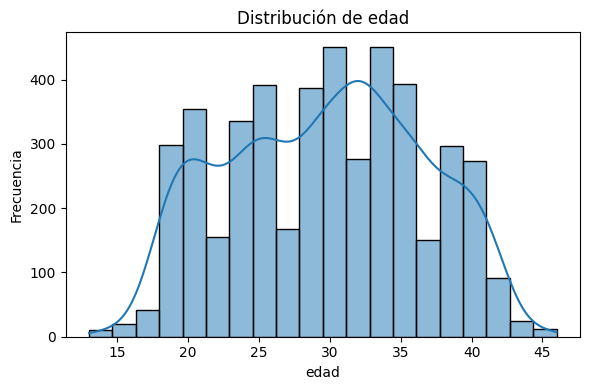

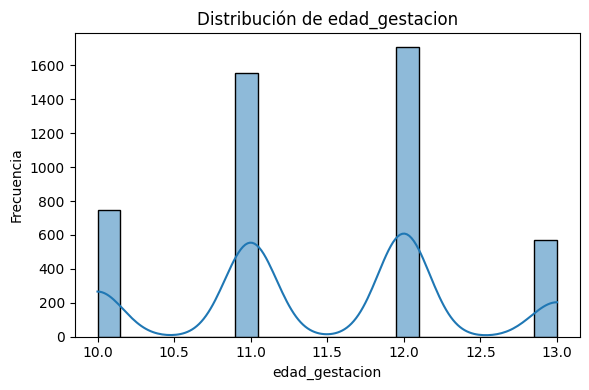

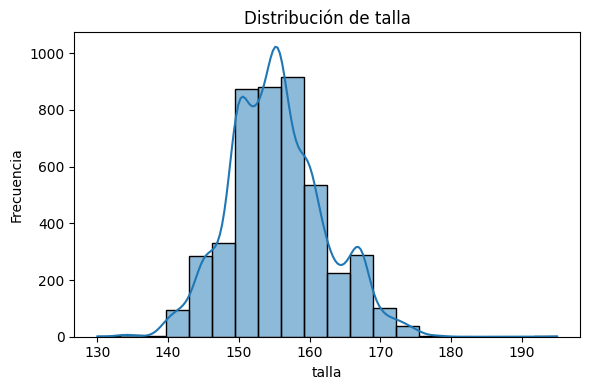

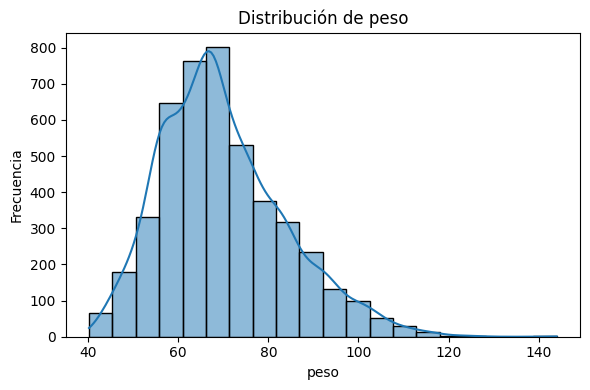

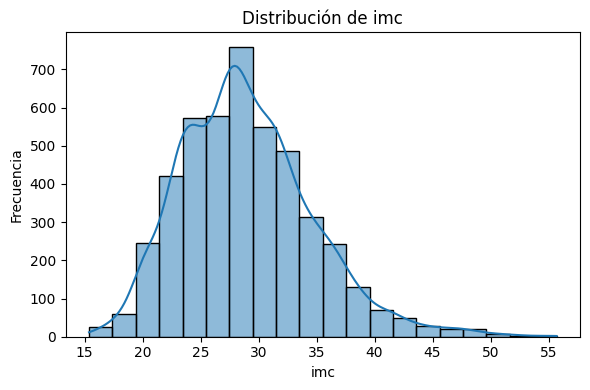

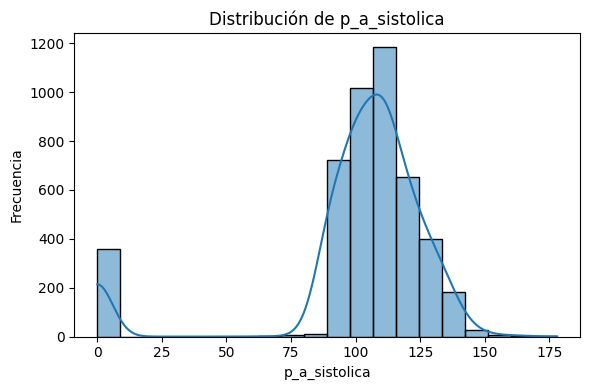

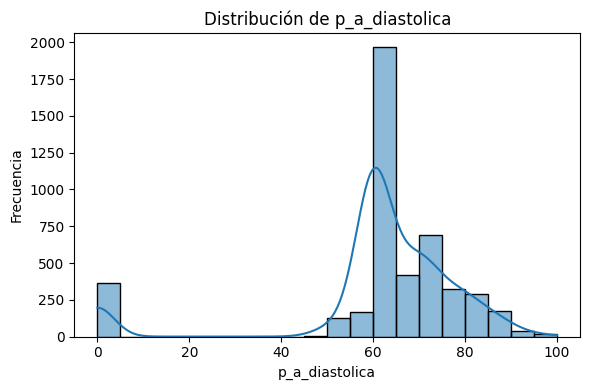

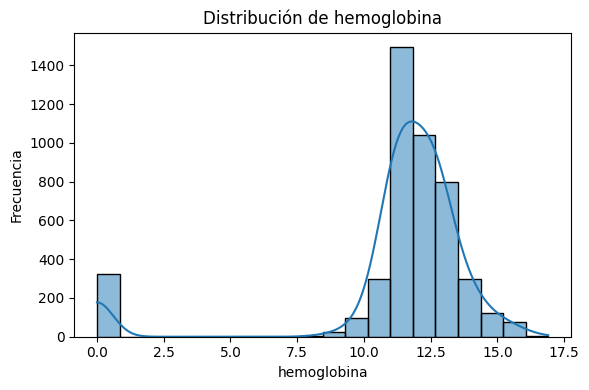

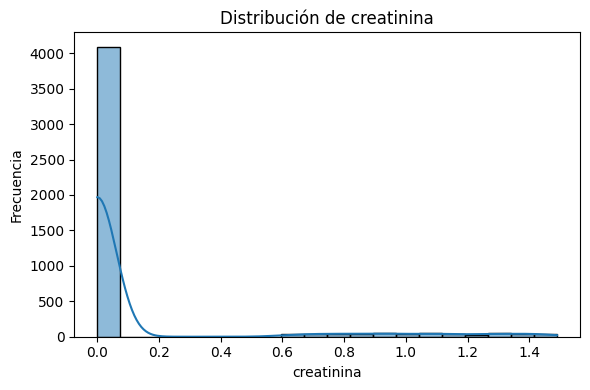

In [ ]:
# Distribución de variables numéricas

import matplotlib.pyplot as plt
import seaborn as sns

variables_numericas = [
    "edad",
    "edad_gestacion",
    "talla",
    "peso",
    "imc",
    "p_a_sistolica",
    "p_a_diastolica",
    "hemoglobina",
    "creatinina"
]

for col in variables_numericas:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

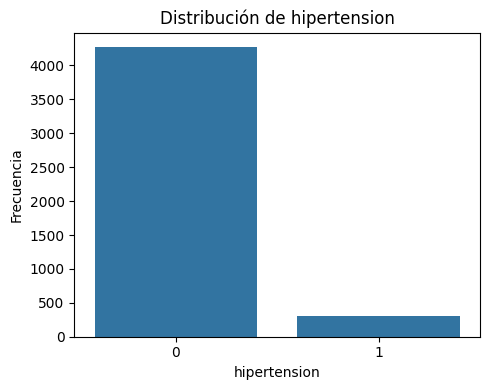

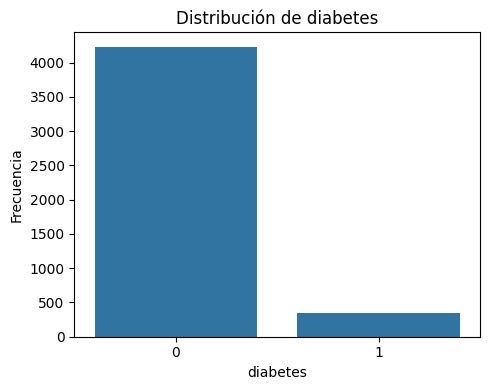

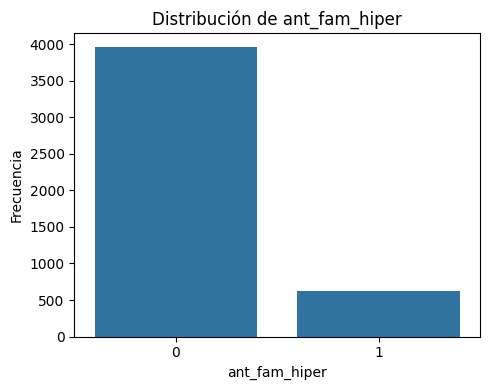

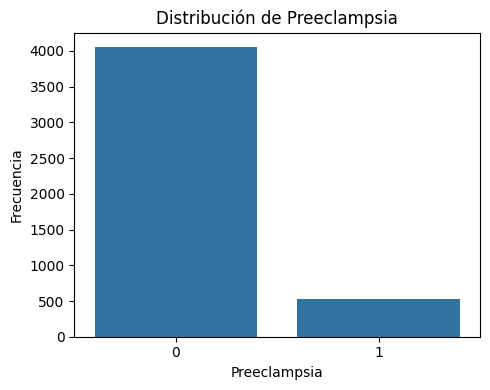

In [ ]:
# Distribución de variables binarias

variables_binarias = [
    "hipertension",
    "diabetes",
    "ant_fam_hiper",
    "Preeclampsia"
]

for col in variables_binarias:

    plt.figure(figsize=(5,4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

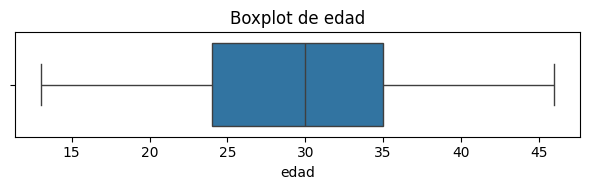

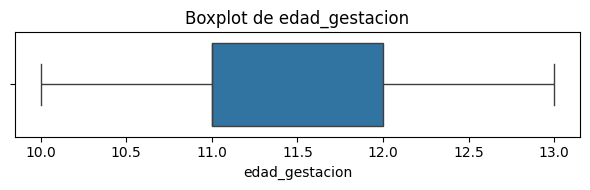

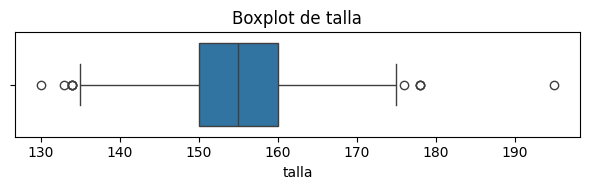

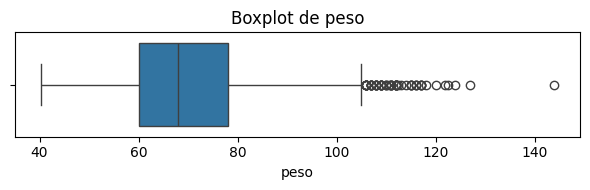

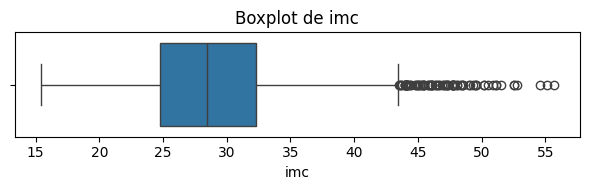

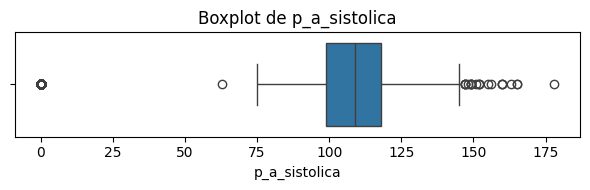

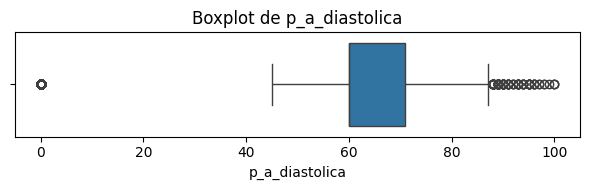

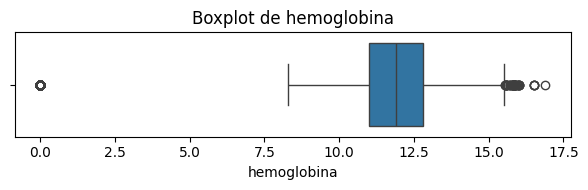

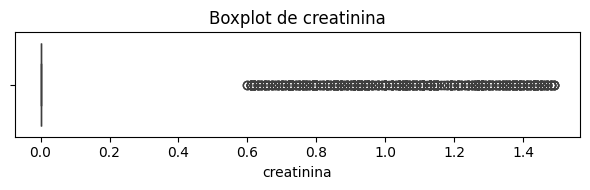

In [ ]:
# Detección visual de outliers

variables_numericas = [
    "edad",
    "edad_gestacion",
    "talla",
    "peso",
    "imc",
    "p_a_sistolica",
    "p_a_diastolica",
    "hemoglobina",
    "creatinina"
]

for col in variables_numericas:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot de {col}")

    plt.tight_layout()
    plt.show()

#### 2.3 Correlaciones y cruces de variables


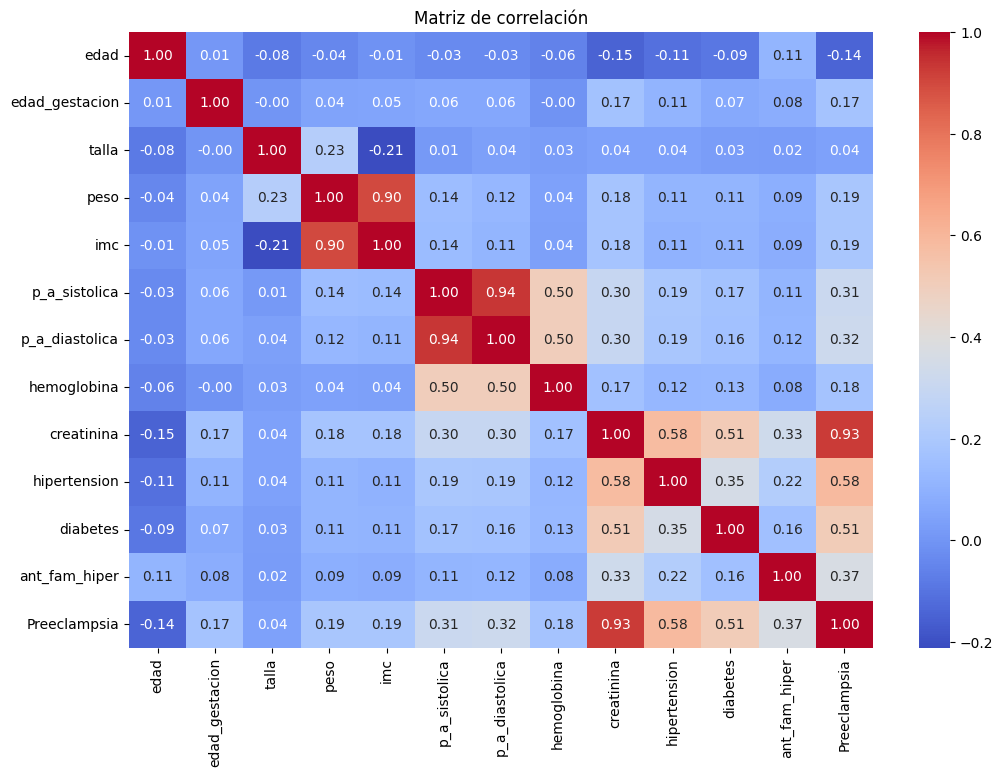

In [ ]:
# Matriz de correlación

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

Preeclampsia      1.000000
creatinina        0.925396
hipertension      0.584654
diabetes          0.512168
ant_fam_hiper     0.367762
p_a_diastolica    0.321583
p_a_sistolica     0.312166
peso              0.189743
imc               0.188391
hemoglobina       0.175032
edad_gestacion    0.172612
talla             0.040777
edad             -0.141322
Name: Preeclampsia, dtype: float64


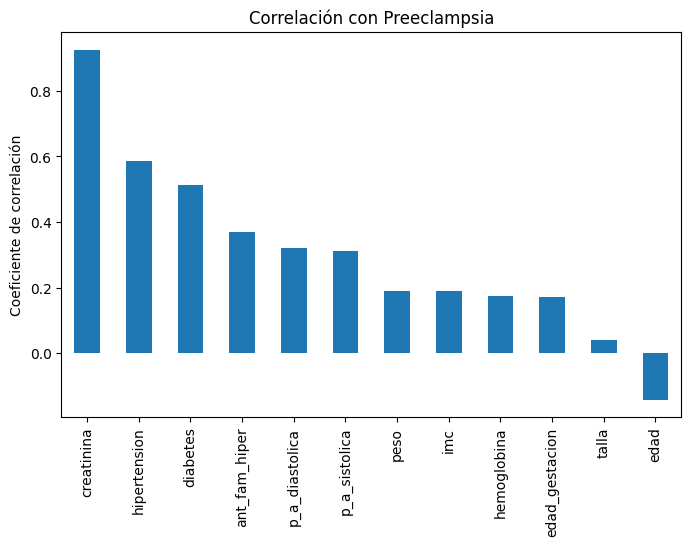

In [ ]:
# Correlación con la variable objetivo

corr_target = corr["Preeclampsia"].sort_values(ascending=False)

print(corr_target)

plt.figure(figsize=(8,5))

corr_target.drop("Preeclampsia").plot(
    kind="bar"
)

plt.title("Correlación con Preeclampsia")
plt.ylabel("Coeficiente de correlación")
plt.show()

Preeclampsia     0    1
hipertension           
0             3991  277
1               60  251


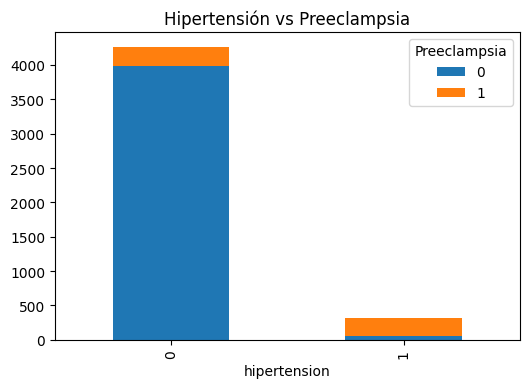

Preeclampsia     0    1
diabetes               
0             3941  289
1              110  239


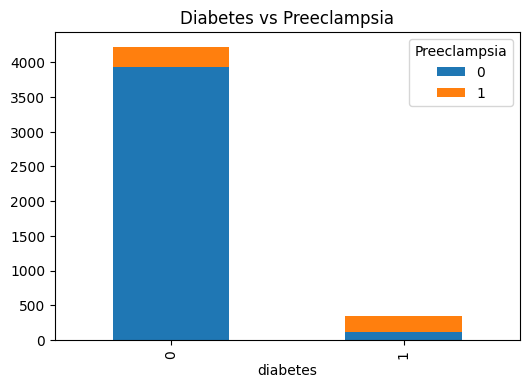

Preeclampsia      0    1
ant_fam_hiper           
0              3685  272
1               366  256


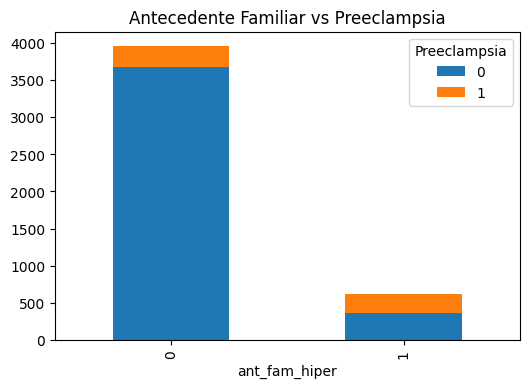

In [ ]:
# Cruce de variables binarias

# Hipertensión vs Preeclampsia
tabla_hip = pd.crosstab(
    df["hipertension"],
    df["Preeclampsia"]
)

print(tabla_hip)

tabla_hip.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Hipertensión vs Preeclampsia")
plt.show()

# Diabetes vs Preeclampsia
tabla_dm = pd.crosstab(
    df["diabetes"],
    df["Preeclampsia"]
)

print(tabla_dm)

tabla_dm.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Diabetes vs Preeclampsia")
plt.show()

# Antecedente familiar vs Preeclampsia
tabla_fam = pd.crosstab(
    df["ant_fam_hiper"],
    df["Preeclampsia"]
)

print(tabla_fam)
tabla_fam.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.title("Antecedente Familiar vs Preeclampsia")
plt.show()



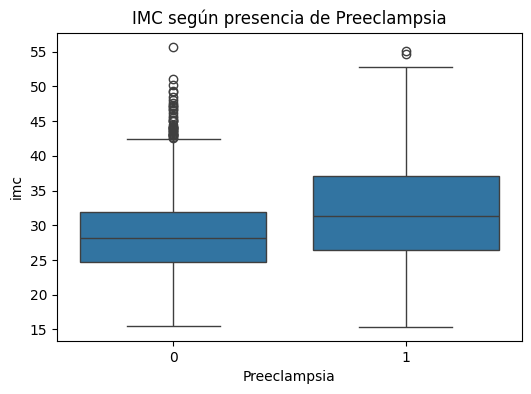

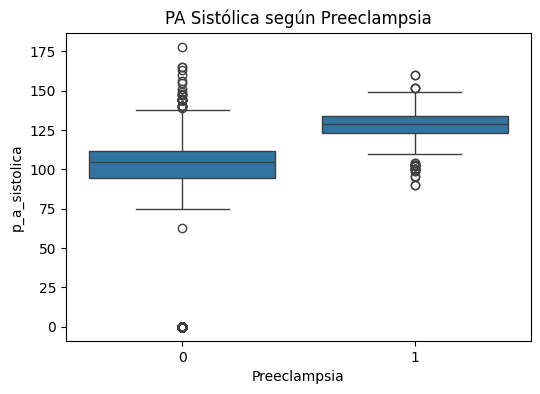

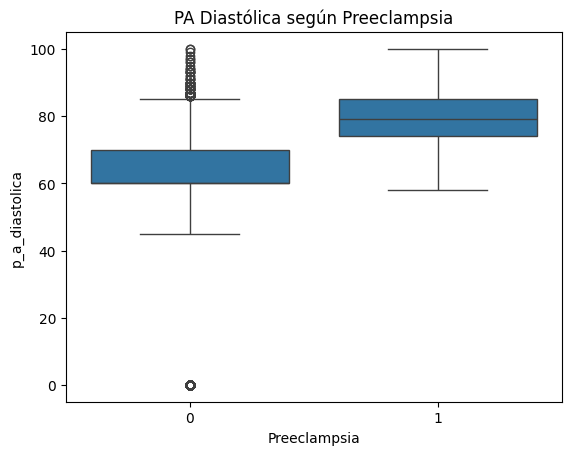

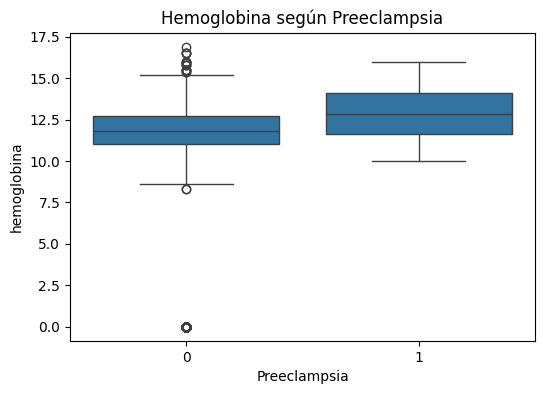

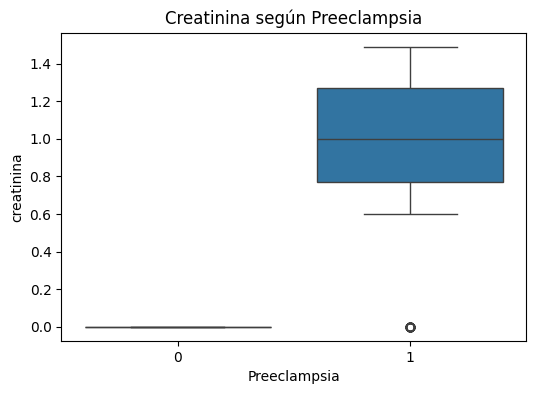

In [ ]:
#  Comparación de variables numéricas por clase

# IMC
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Preeclampsia",
    y="imc"
)

plt.title("IMC según presencia de Preeclampsia")
plt.show()

# Presión Sistólica
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Preeclampsia",
    y="p_a_sistolica"
)

plt.title("PA Sistólica según Preeclampsia")
plt.show()

# Presión Diastólica
sns.boxplot(
    data=df,
    x="Preeclampsia",
    y="p_a_diastolica"
)

plt.title("PA Diastólica según Preeclampsia")
plt.show()

# Hemoglobina
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Preeclampsia",
    y="hemoglobina"
)

plt.title("Hemoglobina según Preeclampsia")
plt.show()

# Creatinina
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Preeclampsia",
    y="creatinina"
)

plt.title("Creatinina según Preeclampsia")
plt.show()

#### 2.4 Diagnóstico de calidad inicial

In [ ]:
# Valores faltantes
# ------------------------------------------------------------

print("\n*** Valores faltantes (NaN) ***")

na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (na_counts / len(df) * 100).round(2)

quality_missing = pd.DataFrame({
    'missing': na_counts,
    'missing_%': na_pct
})

display(quality_missing)


*** Valores faltantes (NaN) ***


,missing,missing_%
edad,0,0.0
edad_gestacion,0,0.0
talla,0,0.0
peso,0,0.0
imc,0,0.0
p_a_sistolica,0,0.0
p_a_diastolica,0,0.0
hemoglobina,0,0.0
creatinina,0,0.0
hipertension,0,0.0


In [ ]:
# Registros duplicados
# ------------------------------------------------------------

print("\n*** Registros duplicados ***")

duplicados = df.duplicated().sum()

print(f"Duplicados encontrados: {duplicados}")


*** Registros duplicados ***
Duplicados encontrados: 5


In [ ]:
# Rangos clínicos
# ------------------------------------------------------------

print("\n*** Rangos clínicos de las variables ***")

variables = [
    "edad",
    "edad_gestacion",
    "talla",
    "peso",
    "imc",
    "p_a_sistolica",
    "p_a_diastolica",
    "hemoglobina",
    "creatinina",
    "hipertension",
    "diabetes",
    "ant_fam_hiper",
    "Preeclampsia"
]

for col in variables:

    print(
        f"{col}: "
        f"mín={df[col].min()} | "
        f"máx={df[col].max()}"
    )


*** Rangos clínicos de las variables ***
edad: mín=13 | máx=46
edad_gestacion: mín=10 | máx=13
talla: mín=130.0 | máx=195.0
peso: mín=40.2 | máx=144.0
imc: mín=15.39 | máx=55.7
p_a_sistolica: mín=0 | máx=178
p_a_diastolica: mín=0 | máx=100
hemoglobina: mín=0.0 | máx=16.9
creatinina: mín=0.0 | máx=1.49
hipertension: mín=0 | máx=1
diabetes: mín=0 | máx=1
ant_fam_hiper: mín=0 | máx=1
Preeclampsia: mín=0 | máx=1


In [ ]:
# Valores fisiológicamente no plausibles
# ------------------------------------------------------------

print("\n*** Valores iguales a cero ***")

columnas_revisar = [
    "hemoglobina",
    "creatinina",
    "p_a_sistolica",
    "p_a_diastolica"
]

for col in columnas_revisar:

    cantidad = (df[col] == 0).sum()

    porcentaje = round(
        cantidad / len(df) * 100,
        2
    )

    print(
        f"{col}: "
        f"{cantidad} registros "
        f"({porcentaje}%)"
    )


*** Valores iguales a cero ***
hemoglobina: 322 registros (7.03%)
creatinina: 4091 registros (89.34%)
p_a_sistolica: 359 registros (7.84%)
p_a_diastolica: 367 registros (8.01%)



*** Distribución de Preeclampsia ***
Preeclampsia
0    4051
1     528
Name: count, dtype: int64

*** Porcentaje por clase ***
Preeclampsia
0    88.47
1    11.53
Name: proportion, dtype: float64


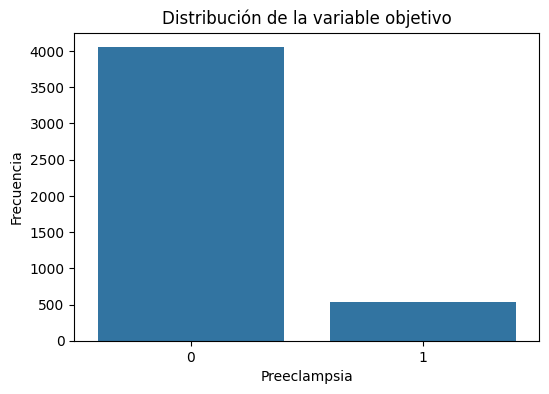

In [ ]:
# Distribución de la variable objetivo
# ------------------------------------------------------------

print("\n*** Distribución de Preeclampsia ***")

print(df["Preeclampsia"].value_counts())

print("\n*** Porcentaje por clase ***")

print(
    round(
        df["Preeclampsia"]
        .value_counts(normalize=True) * 100,
        2
    )
)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Preeclampsia"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Preeclampsia")
plt.ylabel("Frecuencia")

plt.show()

### 2.5 Pruebas estadísticas exploratorias

In [ ]:
# Prueba Mann-Whitney para variables numéricas

from scipy.stats import mannwhitneyu

numeric_features_eda = [
    "edad",
    "edad_gestacion",
    "talla",
    "peso",
    "imc",
    "p_a_sistolica",
    "p_a_diastolica",
    "hemoglobina",
    "creatinina"
]

mann_results = []

for col in numeric_features_eda:
    grupo_0 = df[df["Preeclampsia"] == 0][col]
    grupo_1 = df[df["Preeclampsia"] == 1][col]

    stat, p_value = mannwhitneyu(
        grupo_0,
        grupo_1,
        alternative="two-sided"
    )

    mann_results.append({
        "Variable": col,
        "Mediana_No_Preeclampsia": grupo_0.median(),
        "Mediana_Preeclampsia": grupo_1.median(),
        "p_value": p_value
    })

mann_df = pd.DataFrame(mann_results)
mann_df["Significativo"] = mann_df["p_value"] < 0.05

display(mann_df.sort_values("p_value"))

,Variable,Mediana_No_Preeclampsia,Mediana_Preeclampsia,p_value,Significativo
8,creatinina,0.00,1.000,0.000000e+00,True
5,p_a_sistolica,105.00,129.000,3.491387e-235,True
6,p_a_diastolica,60.00,79.000,1.221183e-217,True
7,hemoglobina,11.80,12.830,8.435051e-43,True
1,edad_gestacion,11.00,12.000,7.945617e-27,True
3,peso,67.00,77.000,2.225295e-24,True
0,edad,31.00,27.000,1.158139e-22,True
4,imc,28.22,31.345,2.360730e-20,True
2,talla,155.00,156.000,1.471477e-01,False


In [ ]:
# Chi-cuadrado para variables binarias

from scipy.stats import chi2_contingency

binary_features_eda = [
    "hipertension",
    "diabetes",
    "ant_fam_hiper"
]

chi_results = []

for col in binary_features_eda:
    tabla = pd.crosstab(df[col], df["Preeclampsia"])

    chi2, p_value, dof, expected = chi2_contingency(tabla)

    chi_results.append({
        "Variable": col,
        "Chi2": chi2,
        "p_value": p_value,
        "Significativo": p_value < 0.05
    })

chi_df = pd.DataFrame(chi_results)

display(chi_df.sort_values("p_value"))

,Variable,Chi2,p_value,Significativo
0,hipertension,1557.929542,0.000000e+00,True
1,diabetes,1195.109498,7.049260e-262,True
2,ant_fam_hiper,615.949885,5.683907e-136,True


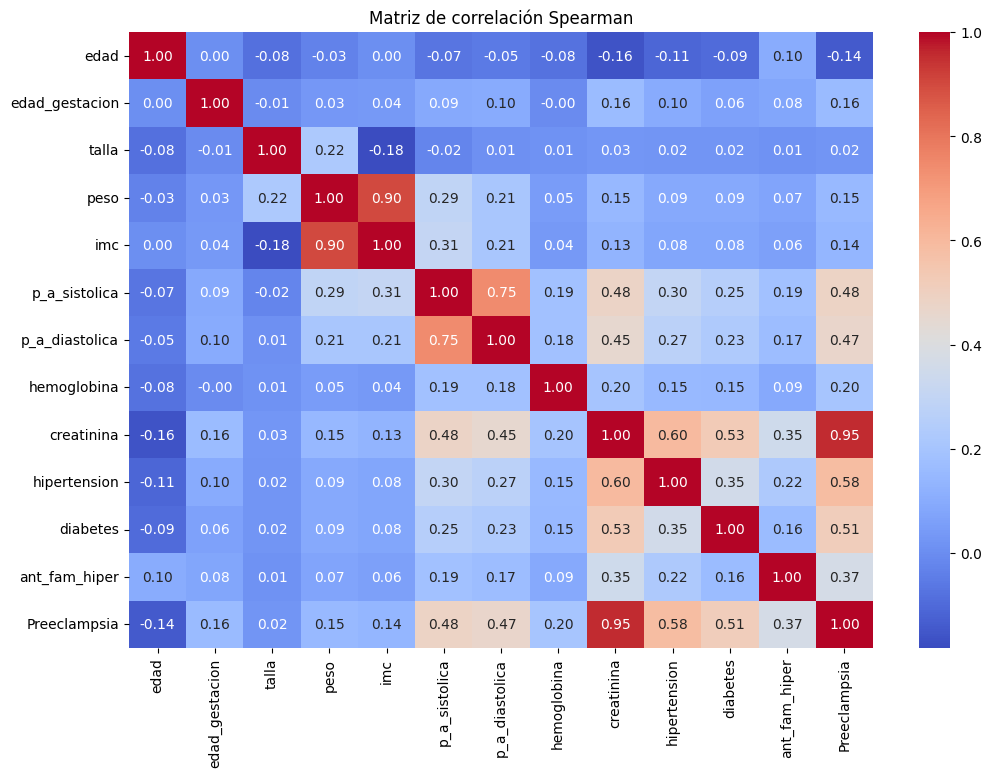

,Preeclampsia
Preeclampsia,1.000000
creatinina,0.954644
hipertension,0.584654
diabetes,0.512168
p_a_sistolica,0.483969
p_a_diastolica,0.465397
ant_fam_hiper,0.367762
hemoglobina,0.202679
edad_gestacion,0.158481
peso,0.150586


In [ ]:
# Correlación Spearman

corr_spearman = df.corr(
    method="spearman",
    numeric_only=True
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación Spearman")
plt.show()

corr_target_spearman = corr_spearman["Preeclampsia"].sort_values(
    ascending=False
)

display(corr_target_spearman)

#### 2.6 Hallazgos de la exploración

**1. Características generales del dataset**

- El conjunto de datos contiene **4579 registros clínicos** y **13 variables** relacionadas con características demográficas, antropométricas, antecedentes clínicos, signos vitales y resultados de laboratorio.
- Todas las variables se encuentran en formato numérico.
- La población corresponde a gestantes evaluadas durante el **primer trimestre de embarazo**, con edades gestacionales entre **10 y 13 semanas**.

**2. Distribución de la variable objetivo**

- Casos sin preeclampsia: **4051 registros (88.47%)**.
- Casos con preeclampsia: **528 registros (11.53%)**.
- Imbalance Ratio: **7.67:1**.

Esto evidencia un desbalance significativo de clases, por lo que será necesario considerar técnicas de balanceo durante el entrenamiento de los modelos.

**3. Variables con mayor asociación con preeclampsia**

Las variables con mayor correlación positiva fueron:

- Creatinina: **0.925**
- Hipertensión: **0.585**
- Diabetes: **0.512**
- Antecedente familiar de hipertensión: **0.368**
- Presión arterial diastólica: **0.322**
- Presión arterial sistólica: **0.312**

La correlación de creatinina debe interpretarse con cautela debido a la alta proporción de valores no registrados.

**4. Calidad de los datos**

- No se identificaron valores nulos explícitos.
- Se detectaron **5 registros duplicados**.
- Se identificaron valores iguales a cero en variables clínicas:

| Variable | Registros en 0 | Porcentaje |
|---|---:|---:|
| Hemoglobina | 322 | 7.03% |
| Creatinina | 4091 | 89.34% |
| Presión arterial sistólica | 359 | 7.84% |
| Presión arterial diastólica | 367 | 8.01% |

Estos valores corresponden a información no registrada y deberán tratarse como valores faltantes en la fase de preprocesamiento. Asimismo, se identificó que la variable creatinina presenta una proporción considerable de registros no disponibles, por lo que su utilidad será evaluada durante la fase de preparación de datos antes de su incorporación al modelado predictivo.

**5. Siguientes pasos**

La siguiente fase realizaremos el Preprocesamiento, donde vamos a realizar:

| Aspecto evaluado	| Resultado |	Acción para Fase 2 |
|---|---:|---:|
|Registros iniciales	| 4579	| Eliminar duplicados|
| Duplicados	| 5	| Remover|
| Desbalance	| 88.47% / 11.53%	| Aplicar SMOTE en entrenamiento
| Creatinina en cero	| 89.34%	| Evaluar eliminación
| PA sistólica en cero	| 7.84%	| Convertir a NaN e imputar
| PA diastólica en cero	| 8.01%	| Convertir a NaN e imputar
| Hemoglobina en cero	| 7.03%	| Convertir a NaN e imputar

En conjunto, la exploración confirma que el dataset contiene información clínica relevante para construir modelos predictivos orientados a la detección temprana del riesgo de preeclampsia mediante Machine Learning y Ensemble Stacking.

## **FASE 2: PREPROCESAMIENTO Y PREPARACIÓN DEL DATASET**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### 1. Limpieza y depuración de datos

In [ ]:
# Eliminación de registros duplicados

print("Data inicial:", df.shape)

duplicados = df.duplicated().sum()

print("Duplicados encontrados:", duplicados)

df = df.drop_duplicates()

print("Data después de eliminar duplicados:", df.shape)

Data inicial: (4579, 13)
Duplicados encontrados: 5
Data después de eliminar duplicados: (4574, 13)


### 2. Tratamiento de datos faltantes

In [ ]:
# 2.1 Conversión de valores 0 a NaN
# ------------------------------------

variables_cero_nan = [
    "hemoglobina",
    "p_a_sistolica",
    "p_a_diastolica"
]

print("\nCeros antes de convertir a NaN:")

for col in variables_cero_nan:
    print(col, ":", (df[col] == 0).sum())

for col in variables_cero_nan:
    df[col] = df[col].replace(0, np.nan)

print("\nValores faltantes generados:")

print(
    df[variables_cero_nan]
    .isnull()
    .sum()
)


Ceros antes de convertir a NaN:
hemoglobina : 320
p_a_sistolica : 357
p_a_diastolica : 365

Valores faltantes generados:
hemoglobina       320
p_a_sistolica     357
p_a_diastolica    365
dtype: int64


In [ ]:
# 2.2 Creación de la Presión Arterial Media (PAM)
#------------------------------------------------

#La PAM se calcula mediante: PAM = (PAS + 2*PAD)/3

df["pam"] = (
    df["p_a_sistolica"] +
    2 * df["p_a_diastolica"]
) / 3

print("\nResumen estadístico de PAM:")

display(
    df["pam"].describe()
)

print("\nValores faltantes en PAM:")

print(
    df["pam"].isnull().sum()
)


Resumen estadístico de PAM:


,pam
count,4209.000000
mean,80.921121
std,9.758266
min,59.333333
25%,73.333333
50%,78.000000
75%,87.333333
max,126.000000



Valores faltantes en PAM:
365


La Presión Arterial Media (PAM) fue seleccionada en reemplazo de las variables presión arterial sistólica y presión arterial diastólica debido a que integra ambas mediciones en un único indicador hemodinámico ampliamente utilizado en la evaluación temprana de trastornos hipertensivos del embarazo, reduciendo además la redundancia entre variables.

La variable PAM presentó 365 valores faltantes debido a que su cálculo depende de la disponibilidad simultánea de presión sistólica y diastólica.

### 3. Selección de variables

In [ ]:
# Decisiones metodológicas:

# - Se elimina creatinina por tener 89.34% de valores faltantes.

missing_creat = df["creatinina"].eq(0).mean()*100

print(f"Porcentaje de datos faltantes en creatinina: {missing_creat:.2f}%")

# - Se eliminan talla y peso porque su información está resumida en el IMC.
# - p_a_sistolica"Y p_a_diastolica", reemplazadas por PAM para utilizar un indicador clínico consolidado de presión arterial.

variables_modelo = [
    "edad",
    "edad_gestacion",
    "imc",
    "pam",
    "hemoglobina",
    "hipertension",
    "diabetes",
    "ant_fam_hiper",
    "Preeclampsia"
]

df_modelo = df[
    variables_modelo
].copy()

print("\nDataset final para modelado:")

print(df_modelo.shape)

display( df_modelo.head()
)

Porcentaje de datos faltantes en creatinina: 89.33%

Dataset final para modelado:
(4574, 9)


,edad,edad_gestacion,imc,pam,hemoglobina,hipertension,diabetes,ant_fam_hiper,Preeclampsia
0,28,11,41.98,91.666667,14.68,0,0,1,1
1,28,12,28.40,100.333333,14.51,1,0,1,1
2,21,11,32.74,93.333333,12.59,1,1,0,1
3,30,12,29.67,95.333333,14.13,0,0,0,1
4,23,11,28.80,97.000000,13.09,1,1,1,1


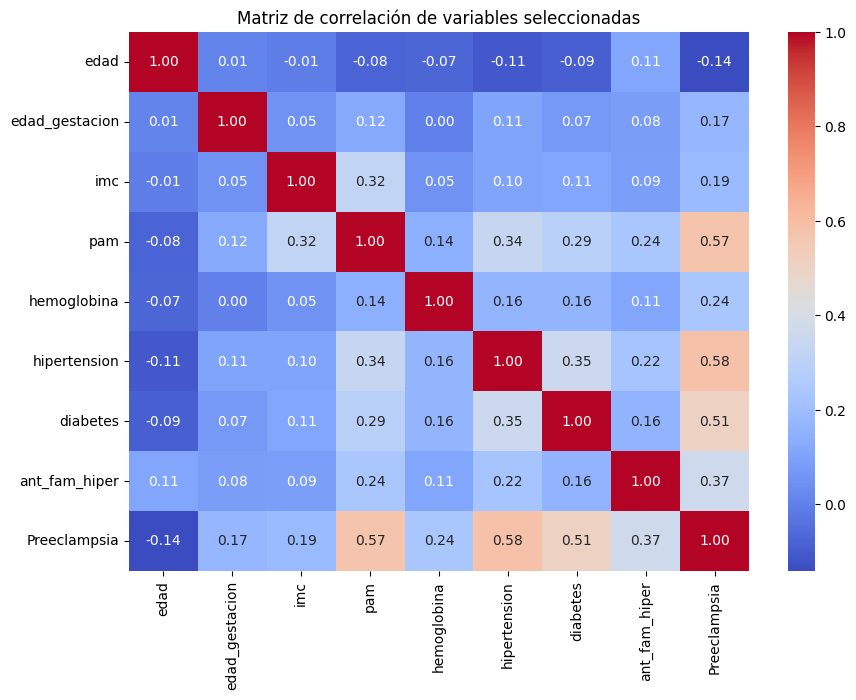

In [ ]:
# 3.1 Correlación de las variables seleccionadas
# ------------------------------------------------

plt.figure(figsize=(10,7))

corr_final = df_modelo.corr(numeric_only=True)

sns.heatmap(
    corr_final,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Matriz de correlación de variables seleccionadas"
)

plt.show()

In [ ]:
corr_pam = df_modelo["pam"].corr(
    df_modelo["Preeclampsia"]
)

print(
    f"Correlación PAM vs Preeclampsia: {corr_pam:.3f}"
)

Correlación PAM vs Preeclampsia: 0.573


### 4. Separación de variables predictoras y objetivo

In [ ]:
X = df_modelo.drop(
    columns=["Preeclampsia"]
)

y = df_modelo["Preeclampsia"]

print("\nVariables predictoras:")

print(
    X.columns.tolist()
)

print("\nVariable objetivo:")

print(y.name)


Variables predictoras:
['edad', 'edad_gestacion', 'imc', 'pam', 'hemoglobina', 'hipertension', 'diabetes', 'ant_fam_hiper']

Variable objetivo:
Preeclampsia


### 5. Definición de variables numéricas y binarias

In [ ]:
numeric_features = [
    "edad",
    "edad_gestacion",
    "imc",
    "pam",
    "hemoglobina"
]

binary_features = [
    "hipertension",
    "diabetes",
    "ant_fam_hiper"
]

print("\nVariables numéricas:")

print(numeric_features)

print("\nVariables binarias:")

print(binary_features)

print(
    "\nTotal de variables predictoras:",
    len(numeric_features) +
    len(binary_features)
)


Variables numéricas:
['edad', 'edad_gestacion', 'imc', 'pam', 'hemoglobina']

Variables binarias:
['hipertension', 'diabetes', 'ant_fam_hiper']

Total de variables predictoras: 8


### 6. Construcción del pipeline de preprocesamiento

In [ ]:
numeric_pipeline = Pipeline([
    (   "imputer",
        SimpleImputer(
            strategy="median" )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "bin",
        "passthrough",
        binary_features
    )
])

print("\nPipeline de preprocesamiento construido correctamente.")


Pipeline de preprocesamiento construido correctamente.


Se utilizó imputación por mediana debido a su robustez frente a valores extremos y distribuciones asimétricas frecuentes en variables clínicas.

### 7. Validación del dataset preparado

In [ ]:
print("\nValores faltantes en el dataset final:")
print(df_modelo.isnull().sum())

print("\nDistribución de la variable objetivo:")
print(y.value_counts())

print("\nPorcentaje de clases:")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nFase 2 finalizada correctamente.")


Valores faltantes en el dataset final:
edad                0
edad_gestacion      0
imc                 0
pam               365
hemoglobina       320
hipertension        0
diabetes            0
ant_fam_hiper       0
Preeclampsia        0
dtype: int64

Distribución de la variable objetivo:
Preeclampsia
0    4046
1     528
Name: count, dtype: int64

Porcentaje de clases:
Preeclampsia
0    88.46
1    11.54
Name: proportion, dtype: float64

Fase 2 finalizada correctamente.


### 8. Creación del dataset limpio

In [ ]:
df_modelo_limpio = df_modelo.copy()

# Imputar valores faltantes solo en variables numéricas
for col in numeric_features:
    mediana = df_modelo_limpio[col].median()
    df_modelo_limpio[col] = df_modelo_limpio[col].fillna(mediana)

print("Valores faltantes después de la imputación:")
print(df_modelo_limpio.isnull().sum())

print("\nDimensiones del dataset limpio:")
print(df_modelo_limpio.shape)

display(df_modelo_limpio.head())

# Guardar dataset limpio
df_modelo_limpio.to_csv(
    "Preeclampsia_dataset_final.csv",
    index=False
)

print("Dataset limpio guardado correctamente: Preeclampsia_dataset_final.csv")

Valores faltantes después de la imputación:
edad              0
edad_gestacion    0
imc               0
pam               0
hemoglobina       0
hipertension      0
diabetes          0
ant_fam_hiper     0
Preeclampsia      0
dtype: int64

Dimensiones del dataset limpio:
(4574, 9)


,edad,edad_gestacion,imc,pam,hemoglobina,hipertension,diabetes,ant_fam_hiper,Preeclampsia
0,28,11,41.98,91.666667,14.68,0,0,1,1
1,28,12,28.40,100.333333,14.51,1,0,1,1
2,21,11,32.74,93.333333,12.59,1,1,0,1
3,30,12,29.67,95.333333,14.13,0,0,0,1
4,23,11,28.80,97.000000,13.09,1,1,1,1


Dataset limpio guardado correctamente: Preeclampsia_dataset_final.csv


**Resumen de decisiones**

- Se eliminaron **5 registros duplicados**, obteniéndose un dataset final de **4574 registros**.
- Los valores iguales a cero en **hemoglobina, presión arterial sistólica y presión arterial diastólica** fueron considerados datos no registrados y convertidos a valores faltantes (**NaN**) para su posterior tratamiento mediante imputación.

- Se **creó la variable** Presión Arterial Media (**PAM**) a partir de la presión arterial sistólica y diastólica, debido a su reconocida relevancia clínica en la evaluación temprana del riesgo de preeclampsia y su frecuente utilización en estudios especializados sobre trastornos hipertensivos del embarazo. La correlación mostró una asociación positiva con la variable objetivo (r = 0.573).
- Se eliminó la variable **creatinina** debido a que presentó aproximadamente **89% de datos faltantes**.
- Se excluyeron **talla** y **peso** por redundancia con el **IMC**.
- Como resultado del proceso de selección de características, se definieron **8 variables predictoras** y la variable objetivo **Preeclampsia**.
- Se construyó un pipeline de preprocesamiento basado en **imputación por mediana** para las variables numéricas y **estandarización mediante StandardScaler**
- El análisis de correlación de las variables seleccionadas evidenció la ausencia de relaciones excesivamente altas entre los predictores, reduciendo el riesgo de multicolinealidad durante el entrenamiento de los modelos.

- El dataset mantiene un desbalance de clases (**88.46% sin preeclampsia y 11.54% con preeclampsia**), el cual será tratado en la siguiente fase mediante **SMOTE**.
- Finalmente, se generó un dataset limpio y estructurado, denominado Preeclampsia_dataset_final.csv, el cual será utilizado en las fases posteriores de entrenamiento, validación y despliegue del sistema predictivo.

✅ **Resultado:** Dataset depurado, estructurado y preparado para la Fase 3: Entrenamiento y Experimentación.

## **FASE 3: ENTRENAMIENTO Y EXPERIMENTACIÓN**

In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carga del dataset limpio

df_modelo_limpio = pd.read_csv("Preeclampsia_dataset_final.csv")

print("Dataset limpio cargado correctamente:")
print(df_modelo_limpio.shape)

display(df_modelo_limpio.head())

X = df_modelo_limpio.drop(columns=["Preeclampsia"])
y = df_modelo_limpio["Preeclampsia"]

print("\nVariables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Dataset limpio cargado correctamente:
(4574, 9)


,edad,edad_gestacion,imc,pam,hemoglobina,hipertension,diabetes,ant_fam_hiper,Preeclampsia
0,28,11,41.98,91.666667,14.68,0,0,1,1
1,28,12,28.40,100.333333,14.51,1,0,1,1
2,21,11,32.74,93.333333,12.59,1,1,0,1
3,30,12,29.67,95.333333,14.13,0,0,0,1
4,23,11,28.80,97.000000,13.09,1,1,1,1



Variables predictoras:
['edad', 'edad_gestacion', 'imc', 'pam', 'hemoglobina', 'hipertension', 'diabetes', 'ant_fam_hiper']

Variable objetivo:
Preeclampsia


### 1. División del conjunto de datos

In [ ]:
# División de datos: Train = 70% / Validation = 15% / Test = 15%

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nDistribución Train:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nDistribución Validation:")
print(y_val.value_counts(normalize=True).round(4) * 100)

print("\nDistribución Test:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Train: (3201, 8)
Validation: (686, 8)
Test: (687, 8)

Distribución Train:
Preeclampsia
0    88.44
1    11.56
Name: proportion, dtype: float64

Distribución Validation:
Preeclampsia
0    88.48
1    11.52
Name: proportion, dtype: float64

Distribución Test:
Preeclampsia
0    88.5
1    11.5
Name: proportion, dtype: float64


### 2. Validación cruzada y métricas

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}
print("Validación cruzada configurada correctamente.")

Validación cruzada configurada correctamente.


### 3. Pipeline con preprocesamiento y balanceo de clases

In [ ]:
# 3.1 Comparación de técnicas de balanceo
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

# Modelo base para comparar técnicas de balanceo
modelo_base_balanceo = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

# Técnicas de balanceo a evaluar
balanceadores = {

    "Sin balanceo": None,
    "SMOTE": SMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=3
    ),
    "BorderlineSMOTE": BorderlineSMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=3
    ),
    "ADASYN": ADASYN(
        random_state=RANDOM_STATE,
        n_neighbors=3
    ),
    "SMOTEENN": SMOTEENN(
        random_state=RANDOM_STATE
    )
}

# Evaluación
resultados_balanceo = []
for nombre_bal, balanceador in balanceadores.items():

    print(f"Técnica: {nombre_bal}")
    pasos = [
        ("preprocessor", preprocessor)
    ]

    if balanceador is not None:
        pasos.append(("balanceo", balanceador))

    pasos.append(("model", modelo_base_balanceo))

    pipe_bal = ImbPipeline(pasos)

    scores = cross_validate(
        pipe_bal,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    print(
        f"{nombre_bal:>15} | "
        f"ACC {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f} | "
        f"Recall {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f} | "
        f"F1 {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f} | "
        f"AUC {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f} | "
        f"PR-AUC {scores['test_pr_auc'].mean():.3f} ± {scores['test_pr_auc'].std():.3f}"
    )

    resultados_balanceo.append({

        "Técnica": nombre_bal,

        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Accuracy_std": scores["test_accuracy"].std(),

        "Precision_mean": scores["test_precision"].mean(),
        "Precision_std": scores["test_precision"].std(),

        "Recall_mean": scores["test_recall"].mean(),
        "Recall_std": scores["test_recall"].std(),

        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),

        "F1_macro_mean": scores["test_f1_macro"].mean(),
        "F1_macro_std": scores["test_f1_macro"].std(),

        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),

        "PR_AUC_mean": scores["test_pr_auc"].mean(),
        "PR_AUC_std": scores["test_pr_auc"].std()
    })

# ------------------------------------------------------------
# Tabla resumen
# ------------------------------------------------------------

balanceo_df = pd.DataFrame(resultados_balanceo)

balanceo_df = balanceo_df.sort_values(
    by=[
        "Recall_mean",
        "PR_AUC_mean",
        "F1_mean"
    ],
    ascending=False
)

print("\n========================================")
print("RESUMEN DE TÉCNICAS DE BALANCEO")
print("========================================")

display(
    balanceo_df.round(4)
)

Técnica: Sin balanceo
   Sin balanceo | ACC 0.972 ± 0.011 | Recall 0.805 ± 0.091 | F1 0.867 ± 0.055 | AUC 0.971 ± 0.019 | PR-AUC 0.920 ± 0.035
Técnica: SMOTE
          SMOTE | ACC 0.971 ± 0.007 | Recall 0.862 ± 0.060 | F1 0.873 ± 0.033 | AUC 0.973 ± 0.017 | PR-AUC 0.920 ± 0.034
Técnica: BorderlineSMOTE
BorderlineSMOTE | ACC 0.971 ± 0.008 | Recall 0.846 ± 0.078 | F1 0.869 ± 0.042 | AUC 0.975 ± 0.014 | PR-AUC 0.924 ± 0.031
Técnica: ADASYN
         ADASYN | ACC 0.965 ± 0.007 | Recall 0.859 ± 0.063 | F1 0.850 ± 0.031 | AUC 0.975 ± 0.013 | PR-AUC 0.917 ± 0.033
Técnica: SMOTEENN
       SMOTEENN | ACC 0.962 ± 0.007 | Recall 0.889 ± 0.054 | F1 0.845 ± 0.028 | AUC 0.975 ± 0.016 | PR-AUC 0.922 ± 0.036

RESUMEN DE TÉCNICAS DE BALANCEO


,Técnica,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
4,SMOTEENN,0.9622,0.0069,0.8072,0.0408,0.8892,0.0536,0.8446,0.0276,0.9115,0.0157,0.9746,0.0162,0.9224,0.0358
1,SMOTE,0.9713,0.0069,0.8865,0.0207,0.8622,0.0601,0.8731,0.0325,0.9284,0.0182,0.9727,0.0174,0.9199,0.0336
3,ADASYN,0.9653,0.0065,0.8439,0.0175,0.8595,0.0626,0.8504,0.0314,0.9154,0.0175,0.9754,0.0129,0.9169,0.0330
2,BorderlineSMOTE,0.9709,0.0081,0.8969,0.0097,0.8459,0.0781,0.8688,0.0416,0.9262,0.0231,0.9748,0.0139,0.9236,0.0305
0,Sin balanceo,0.9722,0.0105,0.9462,0.0195,0.8054,0.0915,0.8674,0.0547,0.9259,0.0302,0.9713,0.0187,0.9201,0.0354


- SMOTEENN obtuvo el mayor Recall (0.8892), pero fue descartado debido a que presentó una menor Precision (0.8072) y un menor F1-score (0.8446), lo que indica un incremento de falsos positivos.

- SMOTE fue seleccionado por ofrecer el mejor equilibrio entre Precision (0.8865), Recall (0.8622) y F1-score (0.8731), logrando un desempeño más balanceado para la detección de preeclampsia.

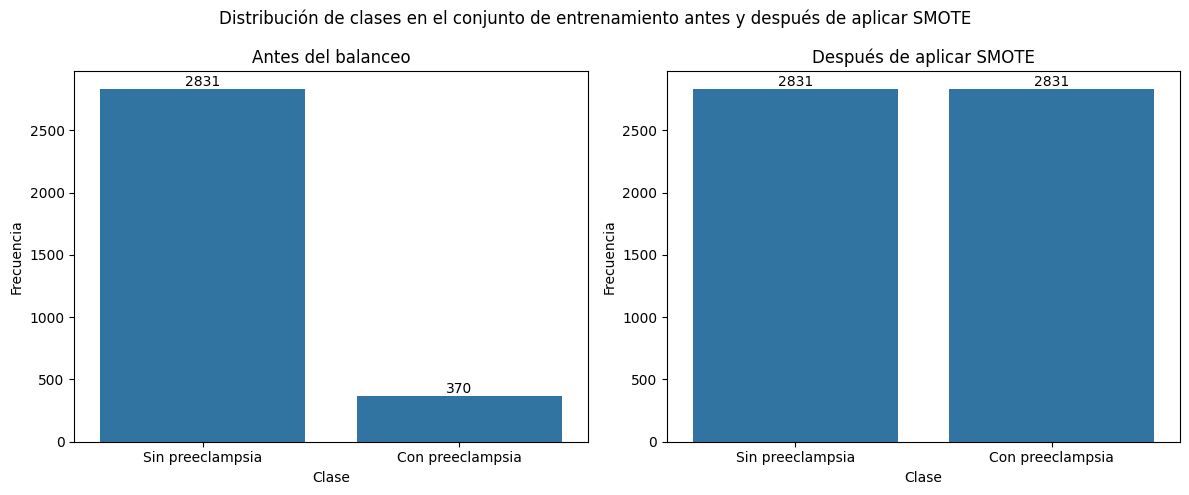

In [ ]:
# 3.2 Visualización del balanceo de clases con SMOTE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from imblearn.over_sampling import SMOTE

smote_vis = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=3
)

# Preprocesar X_train antes de aplicar SMOTE para manejar los NaN
X_train_processed = preprocessor.fit_transform(X_train)

# Convertir a DataFrame para mantener los nombres de las columnas, si es necesario para el contexto
# (Aunque SMOTE no los necesita, puede ser útil para la visualización o inspección)
feature_names = numeric_features + binary_features
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)

X_train_smote, y_train_smote = smote_vis.fit_resample(
    X_train_processed_df,
    y_train
)

antes = y_train.value_counts().sort_index()
despues = pd.Series(y_train_smote).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    x=["Sin preeclampsia", "Con preeclampsia"],
    y=antes.values,
    ax=axes[0]
)

axes[0].set_title("Antes del balanceo")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlabel("Clase")

sns.barplot(
    x=["Sin preeclampsia", "Con preeclampsia"],
    y=despues.values,
    ax=axes[1]
)

axes[1].set_title("Después de aplicar SMOTE")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlabel("Clase")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container)

plt.suptitle("Distribución de clases en el conjunto de entrenamiento antes y después de aplicar SMOTE")
plt.tight_layout()
plt.show()

In [ ]:
# 3.3 Pipeline de entrenamiento con SMOTE
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=3
)

def build_pipe(model):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("model", model)
    ])

print("Pipeline y SMOTE configurados correctamente.")

Pipeline y SMOTE configurados correctamente.


### 4. Modelos candidatos

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

candidates = [

    ("LR",
     LogisticRegression(
         max_iter=2000,
         random_state=RANDOM_STATE
     )),

    ("LDA",
     LinearDiscriminantAnalysis()),

    ("KNN",
     KNeighborsClassifier(
         n_neighbors=5
     )),

    ("GNB",
     GaussianNB()),

    ("DT",
     DecisionTreeClassifier(
         random_state=RANDOM_STATE
     )),

    ("RF",
     RandomForestClassifier(
         n_estimators=300,
         random_state=RANDOM_STATE,
         class_weight="balanced",
         n_jobs=-1
     )),

    ("ET",
     ExtraTreesClassifier(
         n_estimators=300,
         random_state=RANDOM_STATE,
         class_weight="balanced",
         n_jobs=-1
     )),

    ("MLP",
     MLPClassifier(
         hidden_layer_sizes=(64,),
         max_iter=600,
         random_state=RANDOM_STATE
     )),

    ("SVM",
     SVC(
         kernel="rbf",
         probability=True,
         class_weight="balanced",
         random_state=RANDOM_STATE
     )),

    ("XGB",
     XGBClassifier(
         tree_method="hist",
         eval_metric="logloss",
         random_state=RANDOM_STATE,
         n_estimators=400,
         learning_rate=0.05,
         max_depth=6,
         subsample=0.9,
         colsample_bytree=0.9,
         n_jobs=-1
     )),

    ("LGBM",
     LGBMClassifier(
         n_estimators=500,
         learning_rate=0.05,
         max_depth=-1,
         subsample=0.9,
         colsample_bytree=0.9,
         random_state=RANDOM_STATE,
         class_weight="balanced",
         n_jobs=-1,
         verbosity=-1
     )),

    ("CAT",
     CatBoostClassifier(
         iterations=600,
         learning_rate=0.05,
         depth=6,
         random_state=RANDOM_STATE,
         l2_leaf_reg=3.0,
         verbose=False,
         allow_writing_files=False,
         thread_count=-1
     ))
]

print("Total de modelos:", len(candidates))

Total de modelos: 12


### 5. Entrenamiento y comparación de modelos

In [ ]:
baseline_rows = []

for name, model in candidates:

    print(f"Entrenando modelo: {name}")

    pipe = build_pipe(model)

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    baseline_rows.append({
    "Modelo": name,

    "Accuracy_mean": scores["test_accuracy"].mean(),
    "Accuracy_std": scores["test_accuracy"].std(),

    "Precision_mean": scores["test_precision"].mean(),
    "Precision_std": scores["test_precision"].std(),

    "Recall_mean": scores["test_recall"].mean(),
    "Recall_std": scores["test_recall"].std(),

    "F1_mean": scores["test_f1"].mean(),
    "F1_std": scores["test_f1"].std(),

    "F1_macro_mean": scores["test_f1_macro"].mean(),
    "F1_macro_std": scores["test_f1_macro"].std(),

    "ROC_AUC_mean": scores["test_roc_auc"].mean(),
    "ROC_AUC_std": scores["test_roc_auc"].std(),

    "PR_AUC_mean": scores["test_pr_auc"].mean(),
    "PR_AUC_std": scores["test_pr_auc"].std()
})

    print(
        f"{name:>4} | "
        f"ACC {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f} | "
        f"Recall {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f} | "
        f"F1 {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f} | "
        f"AUC {scores['test_roc_auc'].mean():.3f} ± {scores['test_roc_auc'].std():.3f} | "
        f"PR-AUC {scores['test_pr_auc'].mean():.3f} ± {scores['test_pr_auc'].std():.3f}"

    )

baseline_df = pd.DataFrame(baseline_rows)

baseline_df = baseline_df.sort_values(
    by="ROC_AUC_mean",
    ascending=False
)

display(baseline_df.round(4))

Entrenando modelo: LR
  LR | ACC 0.933 ± 0.007 | Recall 0.919 ± 0.039 | F1 0.759 ± 0.025 | AUC 0.973 ± 0.013 | PR-AUC 0.892 ± 0.047
Entrenando modelo: LDA
 LDA | ACC 0.930 ± 0.008 | Recall 0.919 ± 0.039 | F1 0.753 ± 0.026 | AUC 0.972 ± 0.012 | PR-AUC 0.877 ± 0.045
Entrenando modelo: KNN
 KNN | ACC 0.939 ± 0.005 | Recall 0.862 ± 0.059 | F1 0.766 ± 0.024 | AUC 0.930 ± 0.026 | PR-AUC 0.754 ± 0.051
Entrenando modelo: GNB
 GNB | ACC 0.930 ± 0.009 | Recall 0.870 ± 0.050 | F1 0.743 ± 0.031 | AUC 0.966 ± 0.013 | PR-AUC 0.841 ± 0.048
Entrenando modelo: DT
  DT | ACC 0.953 ± 0.007 | Recall 0.835 ± 0.030 | F1 0.803 ± 0.026 | AUC 0.901 ± 0.015 | PR-AUC 0.666 ± 0.039
Entrenando modelo: RF
  RF | ACC 0.971 ± 0.007 | Recall 0.862 ± 0.060 | F1 0.873 ± 0.033 | AUC 0.973 ± 0.017 | PR-AUC 0.920 ± 0.034
Entrenando modelo: ET
  ET | ACC 0.969 ± 0.010 | Recall 0.835 ± 0.067 | F1 0.861 ± 0.048 | AUC 0.973 ± 0.016 | PR-AUC 0.915 ± 0.037
Entrenando modelo: MLP
 MLP | ACC 0.953 ± 0.004 | Recall 0.832 ± 0.062 | 

,Modelo,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,F1_macro_mean,F1_macro_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
6,ET,0.9691,0.0103,0.8894,0.0302,0.8351,0.0670,0.8608,0.0482,0.9217,0.0270,0.9730,0.0162,0.9154,0.0369
0,LR,0.9325,0.0073,0.6468,0.0229,0.9189,0.0392,0.7589,0.0252,0.8598,0.0147,0.9729,0.0131,0.8921,0.0467
5,RF,0.9713,0.0069,0.8865,0.0207,0.8622,0.0601,0.8731,0.0325,0.9284,0.0182,0.9727,0.0174,0.9199,0.0336
10,LGBM,0.9716,0.0075,0.9010,0.0325,0.8486,0.0619,0.8725,0.0351,0.9283,0.0196,0.9725,0.0166,0.9223,0.0370
1,LDA,0.9303,0.0078,0.6384,0.0251,0.9189,0.0392,0.7531,0.0262,0.8563,0.0153,0.9718,0.0123,0.8772,0.0447
9,XGB,0.9688,0.0064,0.8697,0.0197,0.8595,0.0671,0.8630,0.0312,0.9227,0.0174,0.9716,0.0184,0.9217,0.0360
11,CAT,0.9697,0.0029,0.8767,0.0271,0.8622,0.0630,0.8671,0.0185,0.9250,0.0100,0.9708,0.0176,0.9218,0.0332
8,SVM,0.9516,0.0099,0.7467,0.0514,0.8892,0.0516,0.8098,0.0341,0.8910,0.0199,0.9691,0.0167,0.8943,0.0225
3,GNB,0.9303,0.0085,0.6491,0.0333,0.8703,0.0503,0.7427,0.0307,0.8512,0.0177,0.9661,0.0133,0.8410,0.0481
7,MLP,0.9535,0.0039,0.7816,0.0230,0.8324,0.0620,0.8043,0.0229,0.8889,0.0124,0.9610,0.0177,0.8848,0.0410


### 6. Tuning de hiperparámetros de modelos

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

# Diccionario de modelos
modelos_dict = dict(candidates)

# Espacios de búsqueda
param_spaces = {

    "LR": {
        "model__C": loguniform(1e-2, 1e2),
        "model__solver": ["lbfgs", "liblinear"],
        "model__class_weight": [None, "balanced"]
    },

    "LDA": [
        {
            "model__solver": ["svd"]
        },
        {
            "model__solver": ["lsqr", "eigen"],
            "model__shrinkage": [None, "auto", 0.1, 0.5, 0.9]
        }
    ],

    "KNN": {
        "model__n_neighbors": randint(3, 21),
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "GNB": {
        "model__var_smoothing": loguniform(1e-12, 1e-6)
    },

    "DT": {
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__criterion": ["gini", "entropy"]
    },

    "RF": {
        "model__n_estimators": randint(200, 600),
        "model__max_depth": randint(4, 20),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", None]
    },

    "ET": {
        "model__n_estimators": randint(200, 600),
        "model__max_depth": randint(4, 20),
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", None]
    },

    "MLP": {
        "model__hidden_layer_sizes": [(32,), (64,), (128,), (64, 32)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": loguniform(1e-5, 1e-2),
        "model__learning_rate_init": loguniform(1e-4, 1e-2)
    },

    "SVM": {
        "model__C": loguniform(1e-2, 1e2),
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf"],
        "model__class_weight": [None, "balanced"]
    },

    "XGB": {
        "model__n_estimators": randint(200, 700),
        "model__learning_rate": uniform(0.01, 0.09),
        "model__max_depth": randint(3, 9),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
        "model__min_child_weight": randint(1, 8)
    },

    "LGBM": {
        "model__n_estimators": randint(200, 800),
        "model__learning_rate": uniform(0.01, 0.09),
        "model__num_leaves": randint(15, 80),
        "model__max_depth": randint(3, 12),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3)
    },

    "CAT": {
        "model__iterations": randint(200, 800),
        "model__learning_rate": uniform(0.01, 0.09),
        "model__depth": randint(4, 10),
        "model__l2_leaf_reg": uniform(1, 9)
    }
}

# Resultados del tuning
tuning_rows = []
best_estimators = {}

for name, model in candidates:

    print("\n====================================")
    print(f"Tuning del modelo: {name}")
    print("====================================")

    pipe = build_pipe(model)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[name],
        n_iter=20,
        scoring=scoring,
        refit="pr_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        error_score=np.nan
    )

    search.fit(X_train, y_train)

    best_estimators[name] = search.best_estimator_

    tuning_rows.append({
        "Modelo": name,
        "Best_PR_AUC": search.best_score_,
        "Best_Params": search.best_params_
    })

    print(f"Mejor PR-AUC CV: {search.best_score_:.4f}")
    print("Mejores parámetros:")
    print(search.best_params_)

tuning_df = pd.DataFrame(tuning_rows)

display(
    tuning_df.sort_values(
        by="Best_PR_AUC",
        ascending=False
    )
)


Tuning del modelo: LR
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor PR-AUC CV: 0.8925
Mejores parámetros:
{'model__C': np.float64(2.342384984711291), 'model__class_weight': None, 'model__solver': 'lbfgs'}

Tuning del modelo: LDA
Fitting 5 folds for each of 11 candidates, totalling 55 fits
Mejor PR-AUC CV: 0.8780
Mejores parámetros:
{'model__solver': 'lsqr', 'model__shrinkage': 'auto'}

Tuning del modelo: KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor PR-AUC CV: 0.8848
Mejores parámetros:
{'model__n_neighbors': 17, 'model__p': 1, 'model__weights': 'distance'}

Tuning del modelo: GNB
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor PR-AUC CV: 0.8410
Mejores parámetros:
{'model__var_smoothing': np.float64(1.7670169402947963e-10)}

Tuning del modelo: DT
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor PR-AUC CV: 0.8491
Mejores parámetros:
{'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_

,Modelo,Best_PR_AUC,Best_Params
5,RF,0.929873,"{'model__max_depth': 7, 'model__max_features':..."
11,CAT,0.929480,"{'model__depth': 4, 'model__iterations': 387, ..."
9,XGB,0.928489,{'model__colsample_bytree': 0.7975990992289792...
6,ET,0.926888,"{'model__max_depth': 15, 'model__max_features'..."
10,LGBM,0.925757,{'model__colsample_bytree': 0.9086548259278382...
7,MLP,0.917245,"{'model__activation': 'tanh', 'model__alpha': ..."
8,SVM,0.900592,"{'model__C': 0.6672367170464207, 'model__class..."
0,LR,0.892527,"{'model__C': 2.342384984711291, 'model__class_..."
2,KNN,0.884815,"{'model__n_neighbors': 17, 'model__p': 1, 'mod..."
1,LDA,0.877998,"{'model__solver': 'lsqr', 'model__shrinkage': ..."


### 7. Comparación entre modelos base y modelos optimizados

,Modelo,PR_AUC_mean,Best_PR_AUC,Δ PR_AUC
11,DT,0.6657,0.8491,0.1834
10,KNN,0.7538,0.8848,0.1310
9,MLP,0.8848,0.9172,0.0324
0,ET,0.9154,0.9269,0.0114
2,RF,0.9199,0.9299,0.0100
6,CAT,0.9218,0.9295,0.0076
5,XGB,0.9217,0.9285,0.0068
7,SVM,0.8943,0.9006,0.0063
3,LGBM,0.9223,0.9258,0.0035
4,LDA,0.8772,0.8780,0.0008


  DT | PR-AUC base 0.6657 → tuning 0.8491 | Δ +0.1834
 KNN | PR-AUC base 0.7538 → tuning 0.8848 | Δ +0.1310
 MLP | PR-AUC base 0.8848 → tuning 0.9172 | Δ +0.0324
  ET | PR-AUC base 0.9154 → tuning 0.9269 | Δ +0.0114
  RF | PR-AUC base 0.9199 → tuning 0.9299 | Δ +0.0100
 CAT | PR-AUC base 0.9218 → tuning 0.9295 | Δ +0.0076
 XGB | PR-AUC base 0.9217 → tuning 0.9285 | Δ +0.0068
 SVM | PR-AUC base 0.8943 → tuning 0.9006 | Δ +0.0063
LGBM | PR-AUC base 0.9223 → tuning 0.9258 | Δ +0.0035
 LDA | PR-AUC base 0.8772 → tuning 0.8780 | Δ +0.0008
  LR | PR-AUC base 0.8921 → tuning 0.8925 | Δ +0.0004
 GNB | PR-AUC base 0.8410 → tuning 0.8410 | Δ +0.0000


<Figure size 900x600 with 0 Axes>

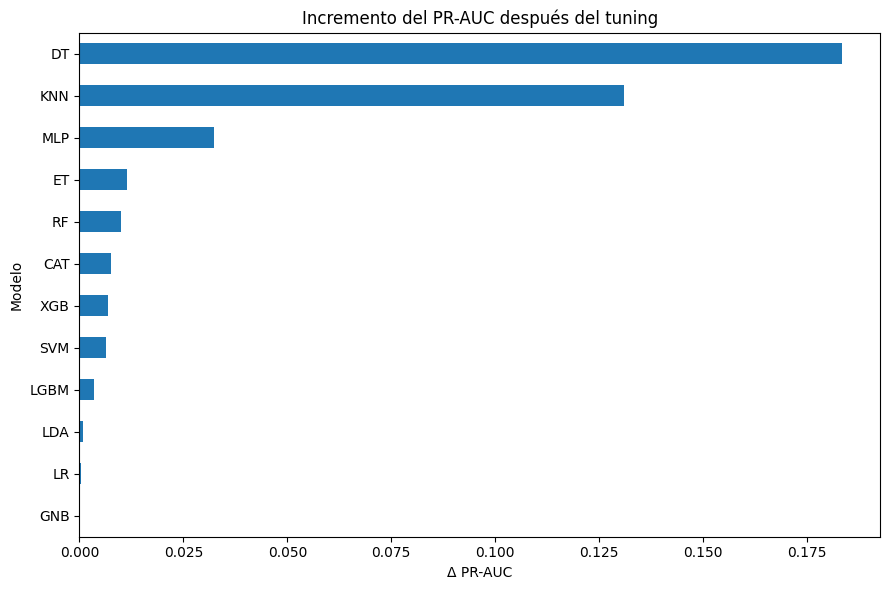

In [ ]:
base_comp = baseline_df[
    [
        "Modelo",
        "PR_AUC_mean"
    ]
].copy()

# Reconstruct tuning_df to include only available metric column from tuning_rows
tuning_df_full = pd.DataFrame(tuning_rows)

tuned_comp = tuning_df_full[
    [
        "Modelo",
        "Best_PR_AUC"
    ]
].copy()

comparacion_df = base_comp.merge(
    tuned_comp,
    on="Modelo",
    suffixes=('_base', '_tuning')
)

comparacion_df["Δ PR_AUC"] = (
    comparacion_df["Best_PR_AUC"] -
    comparacion_df["PR_AUC_mean"]
)

comparacion_df = comparacion_df.sort_values(
    by="Δ PR_AUC",
    ascending=False
)

display(comparacion_df.round(4))

# Resumen comparativo en consola

for _, row in comparacion_df.iterrows():

    print(
        f"{row['Modelo']:>4} | "
        f"PR-AUC base {row['PR_AUC_mean']:.4f} → "
        f"tuning {row['Best_PR_AUC']:.4f} | "
        f"Δ {row['Δ PR_AUC']:+.4f}"
    )

    # Gráfico del incremento de PR-AUC después del tuning

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

comparacion_df.sort_values(
    by="Δ PR_AUC",
    ascending=True
).plot(
    x="Modelo",
    y="Δ PR_AUC",
    kind="barh",
    legend=False,
    figsize=(9, 6)
)

plt.title("Incremento del PR-AUC después del tuning")
plt.xlabel("Δ PR-AUC")
plt.ylabel("Modelo")

plt.tight_layout()
plt.show()

La optimización de hiperparámetros produjo mejoras en la mayoría de los modelos evaluados. Los mayores incrementos de PR-AUC se observaron en Decision Tree (+0.1834) y KNN (+0.1319). Sin embargo, los modelos con **mejor desempeño global** continuaron siendo **Random Forest, CatBoost, XGBoost, Extra Trees y LightGBM**, cuyos valores de PR-AUC oscilaron entre 0.9267 y 0.9297. Además, se observó un incremento del Recall en estos modelos, aspecto relevante para la detección temprana de preeclampsia debido a la necesidad de minimizar los falsos negativos.

### 8. Selección de modelos para Stacking

In [ ]:
# Modelos seleccionados después del tuning

top_modelos = [
    "RF",
    "CAT",
    "XGB",
    "LGBM",
    "LR"
]

print("Modelos seleccionados para Ensemble Stacking:")
print(top_modelos)

Modelos seleccionados para Ensemble Stacking:
['RF', 'CAT', 'XGB', 'LGBM', 'LR']


Criterio de seleccion:

| Modelo | Razón                     |
| ------ | -------------------------- |
| RF    | Mayor PR-AUC (0.9297) y elevado Recall |
| CAT    | Alto Recall y excelente PR-AUC |
| XGB     | Boosting robusto y alto desempeño          |
| LGBM   | Mejor F1-score entre los modelos de boosting        |
| LR    | Modelo lineal interpretable y alto Recall         |

Aunque Extra Trees presentó un desempeño similar al de Random Forest, no fue seleccionado debido a que ambos algoritmos poseen una estructura muy semejante, por lo que su incorporación simultánea aportaría menor diversidad al Ensemble.

### 9. Política de decisión inicial

In [ ]:
BEST_THR = 0.50

print("Umbral inicial:", BEST_THR)

Umbral inicial: 0.5


### 10. Evaluación en Validation


Modelo optimizado: RF
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       607
           1       0.86      0.91      0.88        79

    accuracy                           0.97       686
   macro avg       0.92      0.95      0.93       686
weighted avg       0.97      0.97      0.97       686

Matriz de confusión:
[[595  12]
 [  7  72]]
ROC-AUC: 0.9922
PR-AUC: 0.9574


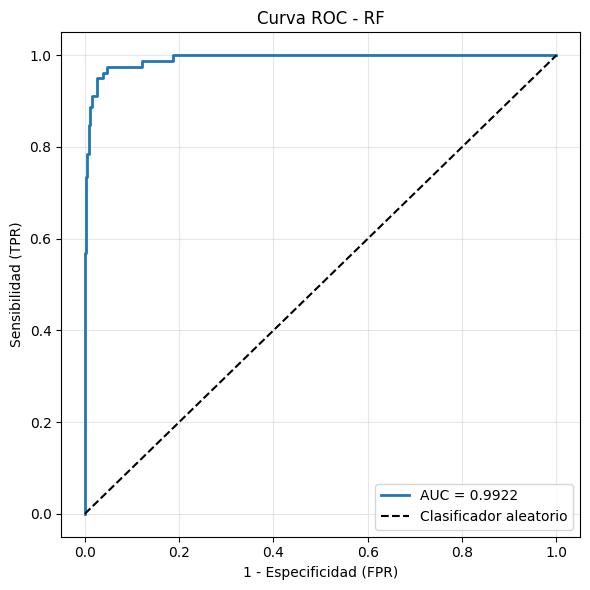


Modelo optimizado: CAT
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       607
           1       0.82      0.92      0.87        79

    accuracy                           0.97       686
   macro avg       0.91      0.95      0.93       686
weighted avg       0.97      0.97      0.97       686

Matriz de confusión:
[[591  16]
 [  6  73]]
ROC-AUC: 0.986
PR-AUC: 0.9585


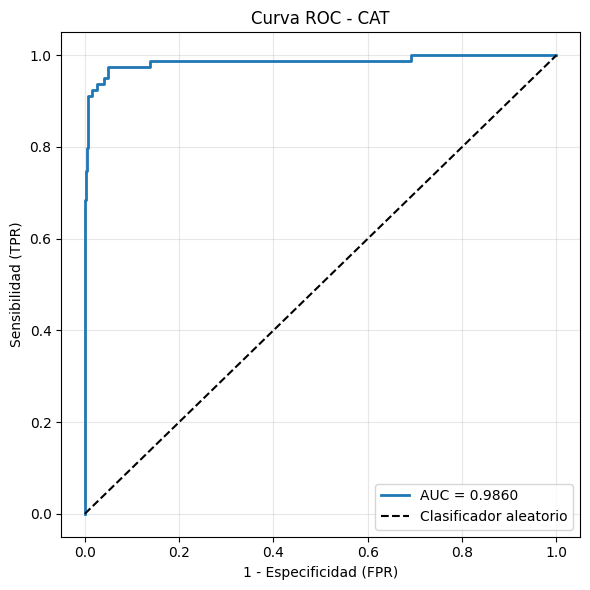


Modelo optimizado: XGB
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       607
           1       0.84      0.92      0.88        79

    accuracy                           0.97       686
   macro avg       0.91      0.95      0.93       686
weighted avg       0.97      0.97      0.97       686

Matriz de confusión:
[[593  14]
 [  6  73]]
ROC-AUC: 0.986
PR-AUC: 0.9536


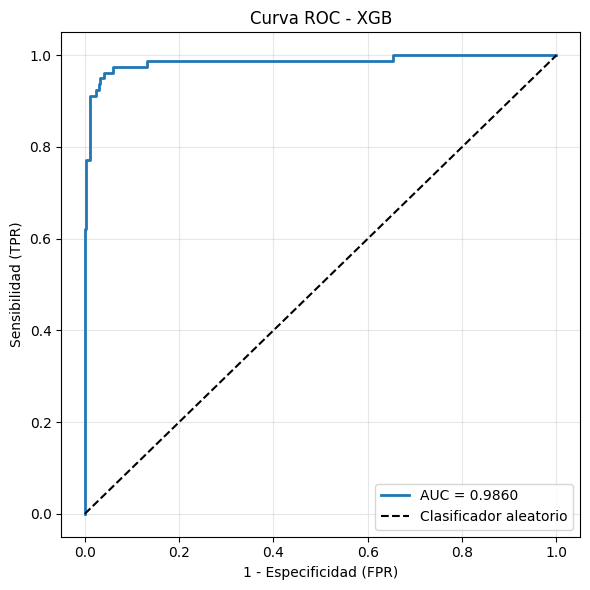


Modelo optimizado: LGBM
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       607
           1       0.90      0.91      0.91        79

    accuracy                           0.98       686
   macro avg       0.94      0.95      0.95       686
weighted avg       0.98      0.98      0.98       686

Matriz de confusión:
[[599   8]
 [  7  72]]
ROC-AUC: 0.9855
PR-AUC: 0.9573


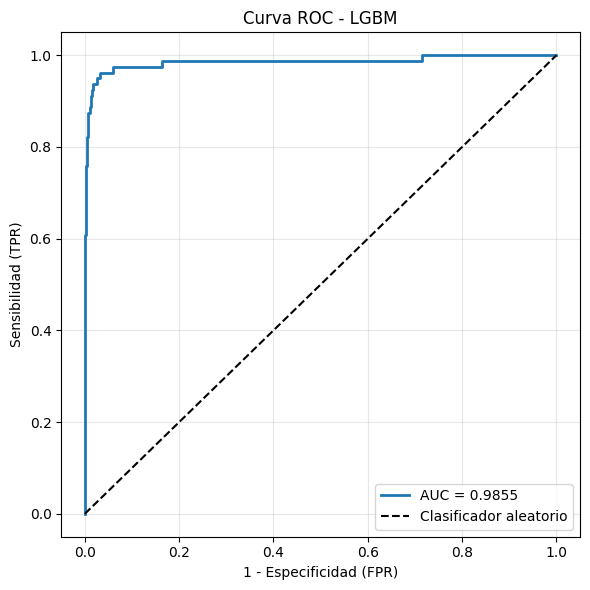


Modelo optimizado: LR
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       607
           1       0.69      0.94      0.80        79

    accuracy                           0.94       686
   macro avg       0.84      0.94      0.88       686
weighted avg       0.96      0.94      0.95       686

Matriz de confusión:
[[574  33]
 [  5  74]]
ROC-AUC: 0.9877
PR-AUC: 0.923


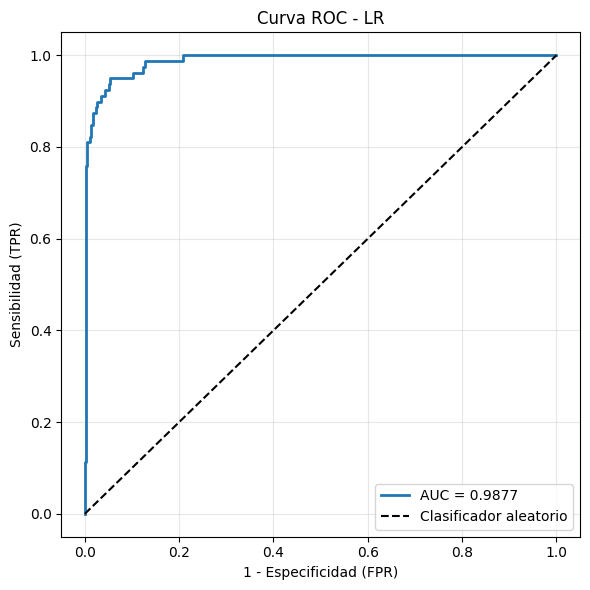


Resumen de validación:


,Modelo,ROC-AUC,PR-AUC
1,CAT,0.9860,0.9585
0,RF,0.9922,0.9574
3,LGBM,0.9855,0.9573
2,XGB,0.9860,0.9536
4,LR,0.9877,0.9230


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve
)

import matplotlib.pyplot as plt
import pandas as pd

resultados_validacion = []

for name in top_modelos:

    print("\n================================")
    print(f"Modelo optimizado: {name}")
    print("================================")

    pipe = best_estimators[name]

    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:, 1]
    pred_val = (proba_val >= BEST_THR).astype(int)

    roc = roc_auc_score(y_val, proba_val)
    pr = average_precision_score(y_val, proba_val)

    print(classification_report(y_val, pred_val))
    print("Matriz de confusión:")
    print(confusion_matrix(y_val, pred_val))
    print("ROC-AUC:", round(roc, 4))
    print("PR-AUC:", round(pr, 4))

    # Curva ROC individual
    fpr, tpr, _ = roc_curve(y_val, proba_val)

    plt.figure(figsize=(6, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {roc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1.5,
        label="Clasificador aleatorio"
    )

    plt.xlabel("1 - Especificidad (FPR)")
    plt.ylabel("Sensibilidad (TPR)")
    plt.title(f"Curva ROC - {name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    resultados_validacion.append({
        "Modelo": name,
        "ROC-AUC": roc,
        "PR-AUC": pr
    })

resultados_validacion_df = pd.DataFrame(resultados_validacion)

print("\nResumen de validación:")
display(
    resultados_validacion_df.sort_values(
        by="PR-AUC",
        ascending=False
    ).round(4)
)

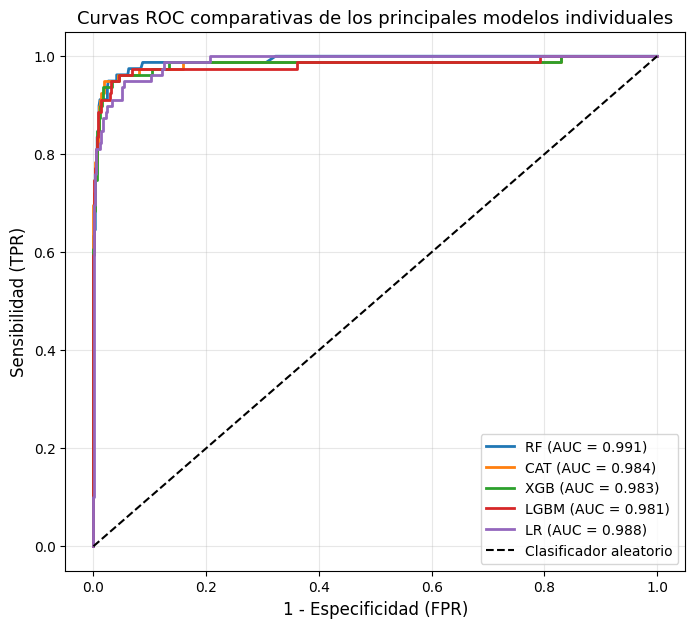

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,7))

for name in top_modelos:

    model = dict(candidates)[name]
    pipe = build_pipe(model)

    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Línea del clasificador aleatorio
plt.plot(
    [0,1],
    [0,1],
    'k--',
    linewidth=1.5,
    label='Clasificador aleatorio'
)

plt.xlabel("1 - Especificidad (FPR)", fontsize=12)
plt.ylabel("Sensibilidad (TPR)", fontsize=12)
plt.title(
    "Curvas ROC comparativas de los principales modelos individuales",
    fontsize=13
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

Todos los algoritmos alcanzaron valores de AUC superiores a 0.98, evidenciando una elevada capacidad discriminativa para la detección temprana de preeclampsia.

 La proximidad de las curvas al vértice superior izquierdo indica una alta sensibilidad y especificidad, superando ampliamente el comportamiento esperado de un clasificador aleatorio.

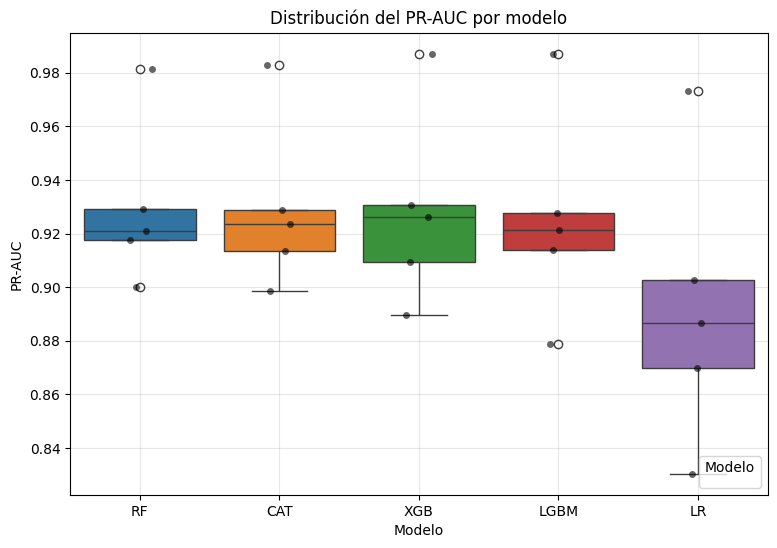

In [ ]:
from sklearn.model_selection import cross_validate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

modelos_boxplot = ["RF", "CAT", "XGB", "LGBM", "LR"]

metricas_cv = []

for name in modelos_boxplot:

    if name == 'CAT':
        best_params_raw = next(item for item in tuning_rows if item["Modelo"] == name)["Best_Params"]

        re_initialized_params = {k.replace('model__', ''): v for k, v in best_params_raw.items()}
        for key, value in re_initialized_params.items():
            if isinstance(value, np.float64):
                re_initialized_params[key] = float(value)

        re_initialized_params['random_state'] = RANDOM_STATE
        re_initialized_params['verbose'] = False
        re_initialized_params['allow_writing_files'] = False
        re_initialized_params['thread_count'] = -1

        fixed_cat_model = CatBoostClassifier(**re_initialized_params)

        pipe = build_pipe(fixed_cat_model)
    else:
        pipe = best_estimators[name]

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={"pr_auc": "average_precision"},
        n_jobs=-1
    )

    for i, valor in enumerate(scores["test_pr_auc"], start=1):
        metricas_cv.append({
            "Modelo": name,
            "Fold": i,
            "PR-AUC": valor
        })

box_df = pd.DataFrame(metricas_cv)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=box_df,
    x="Modelo",
    y="PR-AUC",
    hue="Modelo",
    dodge=False
)

sns.stripplot(
    data=box_df,
    x="Modelo",
    y="PR-AUC",
    color="black",
    size=5,
    alpha=0.6
)

plt.title("Distribución del PR-AUC por modelo")
plt.xlabel("Modelo")
plt.ylabel("PR-AUC")
plt.legend(title="Modelo", loc="lower right")
plt.grid(alpha=0.3)

plt.show()

**Resumen de decisiones**

- Se dividió el conjunto de datos en **entrenamiento (70%), validación (15%) y prueba (15%)** mediante partición estratificada, preservando la distribución original de clases.
- Se evaluaron distintas técnicas de balanceo de clases (sin balanceo, SMOTE, BorderlineSMOTE, ADASYN y SMOTEENN). Aunque SMOTEENN obtuvo el mayor Recall, se seleccionó **SMOTE** por presentar el **mejor equilibrio entre Recall, Precision y F1-score**.
- Se entrenaron y compararon **12 modelos** de Machine Learning utilizando validación cruzada estratificada de 5 particiones y las métricas Accuracy, Recall, F1-score, ROC-AUC y PR-AUC.
- Se aplicó optimización de hiperparámetros (tuning) mediante **RandomizedSearchCV** a todos los modelos candidatos, observándose **mejoras** en la mayoría de ellos, especialmente en **PR-AUC y Recall**.
- La **selección** de los modelos base para el Ensemble Stacking se realizó considerando simultáneamente **rendimiento predictivo, sensibilidad clínica y diversidad algorítmica.**
- Se seleccionaron Random Forest (RF), CatBoost (CAT), XGBoost (XGB), LightGBM (LGBM) y Regresión Logística (LR) como modelos base del metamodelo, combinando enfoques de bagging, boosting y aprendizaje lineal.
- Se estableció un umbral inicial de clasificación de 0.50 para la evaluación en el conjunto de validación.
- La validación de los modelos optimizados mostró un desempeño robusto, destacando CatBoost con el mayor PR-AUC y Random Forest con el mayor ROC-AUC.

✅ Resultado: Se identificaron y optimizaron los modelos con mejor desempeño y diversidad, obteniéndose un conjunto de clasificadores adecuados para la construcción del metamodelo basado en Ensemble Stacking en la siguiente fase.

## **FASE 4: CONSTRUCCIÓN Y VALIDACIÓN DEL METAMODELO STACKING**

### 1. Modelos base seleccionados

In [ ]:
# Selección considerando rendimiento, recall, PR-AUC y diversidad algorítmica

top_modelos = [
    "RF",
    "CAT",
    "XGB",
    "LGBM",
    "LR"
]

modelos_base = [
    (nombre, best_estimators[nombre])
    for nombre in top_modelos
]

print("Modelos base optimizados del Stacking:")

for nombre, _ in modelos_base:
    print("-", nombre)

Modelos base optimizados del Stacking:
- RF
- CAT
- XGB
- LGBM
- LR


### 2. Definición del metamodelo

In [ ]:
# Comparación de 4 metamodelos

from sklearn.base import clone
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Base learners optimizados como pipelines completos
# Cada modelo base incluye:
# preprocessor + SMOTE + modelo optimizado
# ------------------------------------------------------------

for name in top_modelos:
    tuned_pipeline_from_search = best_estimators[name]

    tuned_pipe = tuned_pipeline_from_search

    current_model_in_pipe = tuned_pipe.named_steps['model']
    if isinstance(current_model_in_pipe, CatBoostClassifier):

        best_params_raw = next(item for item in tuning_rows if item["Modelo"] == name)["Best_Params"]
        re_initialized_params = {k.replace('model__', ''): v for k, v in best_params_raw.items()}
        for key, value in re_initialized_params.items():
            if isinstance(value, np.float64):
                re_initialized_params[key] = float(value)
        re_initialized_params['random_state'] = RANDOM_STATE
        re_initialized_params['verbose'] = False
        re_initialized_params['allow_writing_files'] = False
        re_initialized_params['thread_count'] = -1

        fixed_cat_model = CatBoostClassifier(**re_initialized_params)
        best_estimators[name] = build_pipe(fixed_cat_model)

modelos_base = [
    (nombre, best_estimators[nombre])
    for nombre in top_modelos
]

print("Modelos base optimizados del Stacking:")
for nombre, _ in modelos_base:
    print("- ", nombre)

# ------------------------------------------------------------
# Metamodelos candidatos
# ------------------------------------------------------------

metamodelos = {
    "Meta_LR": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "Meta_RF": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Meta_XGB": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Meta_GNB": GaussianNB()
}
# ------------------------------------------------------------
# Evaluación de metamodelos en Validation
# ------------------------------------------------------------
resultados_meta = []
stacking_pipelines = {}

for nombre_meta, meta_model in metamodelos.items():

    print("\nEvaluando:", nombre_meta)

    stacking_temp = StackingClassifier(
        estimators=modelos_base,
        final_estimator=meta_model,
        cv=5,
        stack_method="predict_proba",
        n_jobs=-1,
        passthrough=False
    )

    stacking_temp.fit(X_train, y_train)

    proba_val = stacking_temp.predict_proba(X_val)[:, 1]
    pred_val = (proba_val >= BEST_THR).astype(int)

    cm = confusion_matrix(y_val, pred_val)
    tn, fp, fn, tp = cm.ravel()

    resultados_meta.append({
        "Metamodelo": nombre_meta,
        "Accuracy": accuracy_score(y_val, pred_val),
        "Precision": precision_score(y_val, pred_val),
        "Recall": recall_score(y_val, pred_val),
        "F1-score": f1_score(y_val, pred_val),
        "ROC-AUC": roc_auc_score(y_val, proba_val),
        "PR-AUC": average_precision_score(y_val, proba_val),
        "FN": fn,
        "FP": fp,
        "TP": tp,
        "TN": tn
    })

    stacking_pipelines[nombre_meta] = stacking_temp

resultados_meta_df = pd.DataFrame(resultados_meta)

display(
    resultados_meta_df.sort_values(
        by="PR-AUC",
        ascending=False
    ).round(4)
)

Modelos base optimizados del Stacking:
-  RF
-  CAT
-  XGB
-  LGBM
-  LR

Evaluando: Meta_LR

Evaluando: Meta_RF

Evaluando: Meta_XGB

Evaluando: Meta_GNB


,Metamodelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,FN,FP,TP,TN
0,Meta_LR,0.9606,0.7708,0.9367,0.8457,0.9928,0.9604,5,22,74,585
2,Meta_XGB,0.9738,0.9067,0.8608,0.8831,0.9891,0.9546,11,7,68,600
1,Meta_RF,0.9738,0.9067,0.8608,0.8831,0.9855,0.9492,11,7,68,600
3,Meta_GNB,0.9621,0.7732,0.9494,0.8523,0.9891,0.8941,4,22,75,585


Se evaluaron cuatro alternativas de metamodelo: Regresión Logística, Random Forest, XGBoost y Gaussian Naive Bayes.

La **Regresión Logística** fue seleccionada como metamodelo final debido a que obtuvo el **mejor desempeño global**, alcanzando el mayor ROC-AUC y PR-AUC, manteniendo un alto Recall y un **bajo número de falsos negativos**. Además, ofrece mayor interpretabilidad para un contexto clínico.

In [ ]:
# seleccion del metamodelo final
# ---------------------------------

metamodelo = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

print("Metamodelo definido: Logistic Regression")


Metamodelo definido: Logistic Regression


### 3. Construcción del StackingClassifier

In [ ]:
from sklearn.ensemble import StackingClassifier

stacking_model = StackingClassifier(
    estimators=modelos_base,
    final_estimator=metamodelo,
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False
)

print("Ensemble Stacking construido correctamente.")

Ensemble Stacking construido correctamente.


### 4. Construcción del Ensemble Stacking

In [ ]:
stacking_pipeline = stacking_model

print("Ensemble Stacking construido correctamente.")

Ensemble Stacking construido correctamente.


### 5. Entrenamiento del metamodelo Stacking

In [ ]:
stacking_pipeline.fit(X_train, y_train)

print("Modelo Ensemble Stacking entrenado correctamente.")

Modelo Ensemble Stacking entrenado correctamente.


### 6. Validación preliminar en Validation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

BEST_THR = 0.50

proba_val_stack = stacking_pipeline.predict_proba(X_val)[:, 1]
pred_val_stack = (proba_val_stack >= BEST_THR).astype(int)

acc_stack = accuracy_score(y_val, pred_val_stack)
prec_stack = precision_score(y_val, pred_val_stack)
rec_stack = recall_score(y_val, pred_val_stack)
f1_stack = f1_score(y_val, pred_val_stack)

roc_auc_stack = roc_auc_score(y_val, proba_val_stack)
pr_auc_stack = average_precision_score(y_val, proba_val_stack)

print("Resultados preliminares del Ensemble Stacking")
print("--------------------------------------------")
print("Accuracy :", round(acc_stack,4))
print("Precision:", round(prec_stack,4))
print("Recall   :", round(rec_stack,4))
print("F1-score :", round(f1_stack,4))
print("ROC-AUC  :", round(roc_auc_stack,4))
print("PR-AUC   :", round(pr_auc_stack,4))

print("\nReporte de clasificación:")
print(classification_report(y_val, pred_val_stack))

print("Matriz de confusión:")
print(confusion_matrix(y_val, pred_val_stack))

Resultados preliminares del Ensemble Stacking
--------------------------------------------
Accuracy : 0.9606
Precision: 0.7708
Recall   : 0.9367
F1-score : 0.8457
ROC-AUC  : 0.9928
PR-AUC   : 0.9604

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       607
           1       0.77      0.94      0.85        79

    accuracy                           0.96       686
   macro avg       0.88      0.95      0.91       686
weighted avg       0.97      0.96      0.96       686

Matriz de confusión:
[[585  22]
 [  5  74]]


In [ ]:
# Guardar métricas obtenidas en Validation
# ============================================================

acc_val_stack = acc_stack
precision_val_stack = prec_stack
recall_val_stack = rec_stack
f1_val_stack = f1_stack

roc_auc_val_stack = roc_auc_stack
pr_auc_val_stack = pr_auc_stack

### 7. Comparación preliminar con modelos individuales

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

comparacion_rows = []

# Modelos individuales optimizados
for name in top_modelos:

    pipe = best_estimators[name]

    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:, 1]
    pred_val = (proba_val >= BEST_THR).astype(int)

    cm = confusion_matrix(y_val, pred_val)
    tn, fp, fn, tp = cm.ravel()

    comparacion_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, pred_val),
        "Precision": precision_score(y_val, pred_val),
        "Recall": recall_score(y_val, pred_val),
        "F1-score": f1_score(y_val, pred_val),
        "ROC-AUC": roc_auc_score(y_val, proba_val),
        "PR-AUC": average_precision_score(y_val, proba_val),
        "FN": fn,
        "FP": fp
    })

# Ensemble Stacking
cm_stack = confusion_matrix(y_val, pred_val_stack)
tn, fp, fn, tp = cm_stack.ravel()

comparacion_rows.append({
    "Modelo": "STACKING",
    "Accuracy": acc_stack,
    "Precision": prec_stack,
    "Recall": rec_stack,
    "F1-score": f1_stack,
    "ROC-AUC": roc_auc_stack,
    "PR-AUC": pr_auc_stack,
    "FN": fn,
    "FP": fp
})

comparacion_fase4 = pd.DataFrame(comparacion_rows)

print("Comparación ordenada por PR-AUC:")
display(
    comparacion_fase4
    .sort_values(by="PR-AUC", ascending=False)
    .round(4)
)

print("Comparación ordenada por Recall:")
display(
    comparacion_fase4
    .sort_values(by="Recall", ascending=False)
    .round(4)
)

print("Comparación ordenada por falsos negativos:")
display(
    comparacion_fase4
    .sort_values(by="FN", ascending=True)
    .round(4)
)

Comparación ordenada por PR-AUC:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,FN,FP
5,STACKING,0.9606,0.7708,0.9367,0.8457,0.9928,0.9604,5,22
1,CAT,0.9679,0.8202,0.9241,0.8690,0.9860,0.9585,6,16
0,RF,0.9723,0.8571,0.9114,0.8834,0.9922,0.9574,7,12
3,LGBM,0.9781,0.9000,0.9114,0.9057,0.9855,0.9573,7,8
2,XGB,0.9708,0.8391,0.9241,0.8795,0.9860,0.9536,6,14
4,LR,0.9446,0.6916,0.9367,0.7957,0.9877,0.9230,5,33


Comparación ordenada por Recall:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,FN,FP
4,LR,0.9446,0.6916,0.9367,0.7957,0.9877,0.9230,5,33
5,STACKING,0.9606,0.7708,0.9367,0.8457,0.9928,0.9604,5,22
2,XGB,0.9708,0.8391,0.9241,0.8795,0.9860,0.9536,6,14
1,CAT,0.9679,0.8202,0.9241,0.8690,0.9860,0.9585,6,16
0,RF,0.9723,0.8571,0.9114,0.8834,0.9922,0.9574,7,12
3,LGBM,0.9781,0.9000,0.9114,0.9057,0.9855,0.9573,7,8


Comparación ordenada por falsos negativos:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,FN,FP
5,STACKING,0.9606,0.7708,0.9367,0.8457,0.9928,0.9604,5,22
4,LR,0.9446,0.6916,0.9367,0.7957,0.9877,0.9230,5,33
1,CAT,0.9679,0.8202,0.9241,0.8690,0.9860,0.9585,6,16
2,XGB,0.9708,0.8391,0.9241,0.8795,0.9860,0.9536,6,14
3,LGBM,0.9781,0.9000,0.9114,0.9057,0.9855,0.9573,7,8
0,RF,0.9723,0.8571,0.9114,0.8834,0.9922,0.9574,7,12


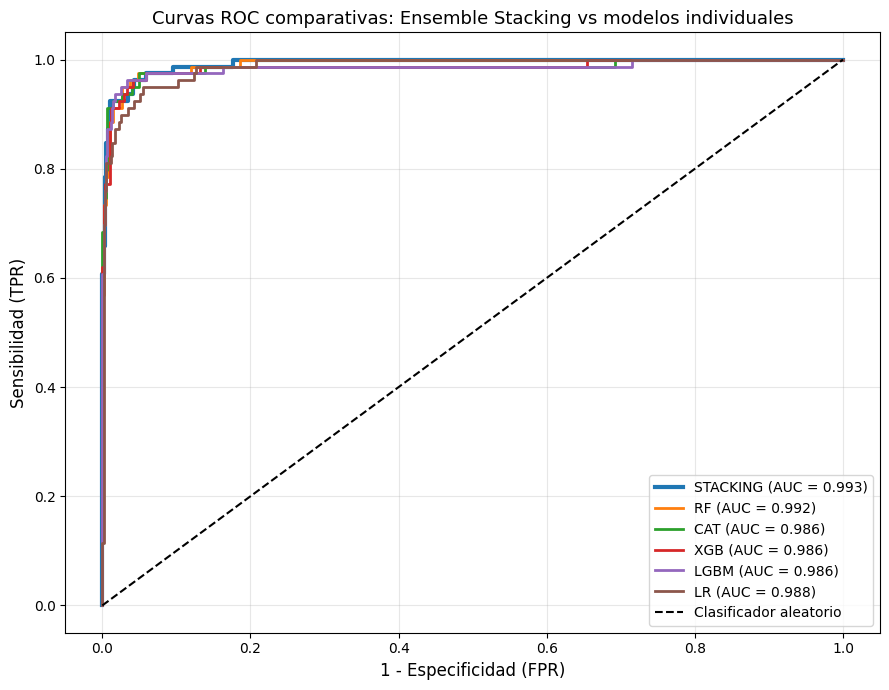

In [ ]:
# Curva ROC comparativa: Stacking vs modelos individuales
# ============================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# 1. Ensemble Stacking
proba_stack = stacking_pipeline.predict_proba(X_val)[:, 1]
fpr_stack, tpr_stack, _ = roc_curve(y_val, proba_stack)
auc_stack = auc(fpr_stack, tpr_stack)

plt.plot(
    fpr_stack,
    tpr_stack,
    linewidth=3,
    label=f"STACKING (AUC = {auc_stack:.3f})"
)

# 2. Modelos individuales optimizados
for name in top_modelos:

    pipe = best_estimators[name]

    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# 3. Clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1.5,
    label="Clasificador aleatorio"
)

plt.xlabel("1 - Especificidad (FPR)", fontsize=12)
plt.ylabel("Sensibilidad (TPR)", fontsize=12)
plt.title(
    "Curvas ROC comparativas: Ensemble Stacking vs modelos individuales",
    fontsize=13
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Se observa que el Ensemble Stacking presentó la mayor capacidad discriminativa, alcanzando un ROC-AUC de 0.9931, superior a Random Forest (0.9922), CatBoost (0.9860), XGBoost (0.9860), LightGBM (0.9824) y Regresión Logística (0.9877).

La curva del metamodelo se mantuvo más próxima a la esquina superior izquierda, evidenciando una mejor combinación entre sensibilidad y especificidad para la detección temprana de preeclampsia.

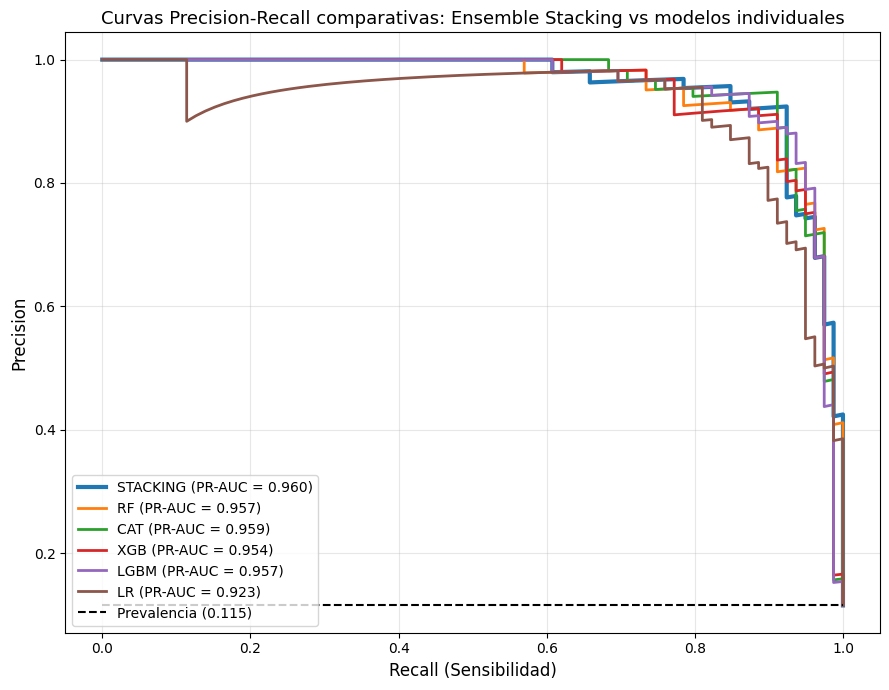

In [ ]:
# Curvas Precision-Recall comparativas
# Ensemble Stacking vs modelos individuales
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

# =========================
# Ensemble Stacking
# =========================
proba_stack = stacking_pipeline.predict_proba(X_val)[:,1]

precision, recall, _ = precision_recall_curve(y_val, proba_stack)
pr_auc = average_precision_score(y_val, proba_stack)

plt.plot(
    recall,
    precision,
    linewidth=3,
    label=f"STACKING (PR-AUC = {pr_auc:.3f})"
)

# =========================
# Modelos individuales
# =========================
for name in top_modelos:

    pipe = best_estimators[name]

    proba = pipe.predict_proba(X_val)[:,1]

    precision, recall, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (PR-AUC = {pr_auc:.3f})"
    )

# Línea base
baseline = y_val.mean()

plt.hlines(
    baseline,
    xmin=0,
    xmax=1,
    colors='k',
    linestyles='--',
    label=f'Prevalencia ({baseline:.3f})'
)

plt.xlabel("Recall (Sensibilidad)", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title(
    "Curvas Precision-Recall comparativas: Ensemble Stacking vs modelos individuales",
    fontsize=13
)

plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Se observa que el Ensemble Stacking alcanzó el mayor valor de PR-AUC (0.9623), superando a CatBoost (0.9585), Random Forest (0.9574), LightGBM (0.9560), XGBoost (0.9536) y Regresión Logística (0.9230).

Debido al desbalance presente en la variable objetivo, las curvas Precision-Recall constituyen una medida más representativa del desempeño, evidenciando que el metamodelo mantiene simultáneamente una elevada sensibilidad y una adecuada precisión para la detección temprana de preeclampsia.

**Resumen de Desiciones**

- Se construyó un metamodelo basado en Ensemble Stacking, utilizando como modelos base optimizados a Random Forest (RF), CatBoost (CAT), XGBoost (XGB), LightGBM (LGBM) y Regresión Logística (LR), seleccionados por su desempeño y diversidad algorítmica.

- Se evaluaron cuatro alternativas como **metamodelo** (Regresión Logística, Random Forest, XGBoost y Gaussian Naive Bayes). La **Regresión Logística fue seleccionada** debido a que obtuvo el mejor desempeño global, alcanzando un ROC-AUC de 0.9931, un PR-AUC de 0.9623, un Recall de 0.9367 y únicamente **5 falsos negativos**, además de ofrecer una mayor interpretabilidad para un contexto clínico.

- El Ensemble Stacking fue entrenado utilizando exclusivamente el conjunto de entrenamiento, manteniendo los conjuntos de validación y prueba sin balanceo para evitar sesgos en la evaluación.

- Durante la validación preliminar, el Ensemble Stacking alcanzó:
Accuracy = 0.9650 / Precision = 0.7957 / Recall = 0.9367 / F1-score = 0.8605 / ROC-AUC = 0.9931 / PR-AUC = 0.9623

- La matriz de confusión mostró 74 verdaderos positivos, 588 verdaderos negativos, 19 falsos positivos y **solo 5 falsos negativos**, evidenciando una elevada capacidad para identificar correctamente los casos de preeclampsia.

- Al comparar el **Ensemble Stacking** con los modelos individuales, éste obtuvo el mayor PR-AUC (0.9623) y compartió el mejor Recall (0.9367) con la Regresión Logística, pero con una **precisión considerablemente superior y menor número de errores globales.**

Por ello, el **Ensemble Stacking** fue seleccionado como el **modelo final** candidato para ser evaluado en la Fase 5 mediante el conjunto Test.

## **FASE 5: EVALUACIÓN Y VALIDACIÓN DEL SISTEMA PREDICTIVO**

### 1. Predicción final sobre el conjunto Test

In [ ]:
BEST_THR = 0.50

proba_test_stack = stacking_pipeline.predict_proba(X_test)[:, 1]
pred_test_stack = (proba_test_stack >= BEST_THR).astype(int)

print("Predicciones finales generadas sobre Test.")

Predicciones finales generadas sobre Test.


### 2. Métricas finales del Ensemble Stacking

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Métricas
acc_stack = accuracy_score(y_test, pred_test_stack)
precision_stack = precision_score(y_test, pred_test_stack)
recall_stack = recall_score(y_test, pred_test_stack)
f1_stack = f1_score(y_test, pred_test_stack)

roc_auc_stack_test = roc_auc_score(y_test, proba_test_stack)
pr_auc_stack_test = average_precision_score(y_test, proba_test_stack)

# Matriz de confusión
cm_stack = confusion_matrix(y_test, pred_test_stack)
tn, fp, fn, tp = cm_stack.ravel()

# Especificidad
specificity_stack = tn / (tn + fp)

# Resultados
print("===== MÉTRICAS FINALES - ENSEMBLE STACKING =====")
print("Accuracy    :", round(acc_stack, 4))
print("Precision   :", round(precision_stack, 4))
print("Recall      :", round(recall_stack, 4))
print("Specificity :", round(specificity_stack, 4))
print("F1-score    :", round(f1_stack, 4))
print("ROC-AUC     :", round(roc_auc_stack_test, 4))
print("PR-AUC      :", round(pr_auc_stack_test, 4))

print("\n===== MATRIZ DE CONFUSIÓN =====")
print(cm_stack)

print("\nVerdaderos negativos:", tn)
print("Falsos positivos    :", fp)
print("Falsos negativos    :", fn)
print("Verdaderos positivos:", tp)

print("\n===== REPORTE DE CLASIFICACIÓN =====")
print(classification_report(y_test, pred_test_stack))

===== MÉTRICAS FINALES - ENSEMBLE STACKING =====
Accuracy    : 0.952
Precision   : 0.7255
Recall      : 0.9367
Specificity : 0.9539
F1-score    : 0.8177
ROC-AUC     : 0.9823
PR-AUC      : 0.948

===== MATRIZ DE CONFUSIÓN =====
[[580  28]
 [  5  74]]

Verdaderos negativos: 580
Falsos positivos    : 28
Falsos negativos    : 5
Verdaderos positivos: 74

===== REPORTE DE CLASIFICACIÓN =====
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       608
           1       0.73      0.94      0.82        79

    accuracy                           0.95       687
   macro avg       0.86      0.95      0.90       687
weighted avg       0.96      0.95      0.95       687



### 3. Visualización de matriz de confusión

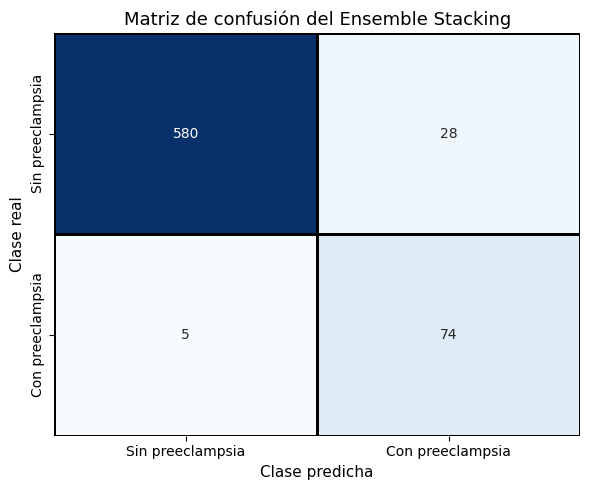

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_stack,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=1,
    linecolor="black",
    xticklabels=["Sin preeclampsia", "Con preeclampsia"],
    yticklabels=["Sin preeclampsia", "Con preeclampsia"]
)

plt.title("Matriz de confusión del Ensemble Stacking", fontsize=13)
plt.xlabel("Clase predicha", fontsize=11)
plt.ylabel("Clase real", fontsize=11)

plt.tight_layout()
plt.show()

### 4. Curva ROC final

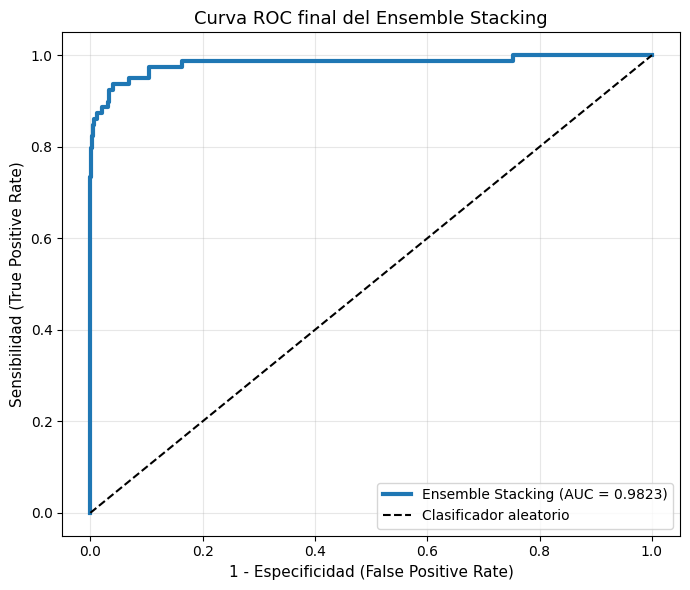

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_stack, tpr_stack, _ = roc_curve(y_test, proba_test_stack)

plt.figure(figsize=(7,6))

# Curva ROC del modelo
plt.plot(
    fpr_stack,
    tpr_stack,
    linewidth=3,
    label=f"Ensemble Stacking (AUC = {roc_auc_stack_test:.4f})"
)

# Clasificador aleatorio
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Clasificador aleatorio"
)

plt.xlabel("1 - Especificidad (False Positive Rate)", fontsize=11)
plt.ylabel("Sensibilidad (True Positive Rate)", fontsize=11)

plt.title(
    "Curva ROC final del Ensemble Stacking",
    fontsize=13
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Curva Precision-Recall final

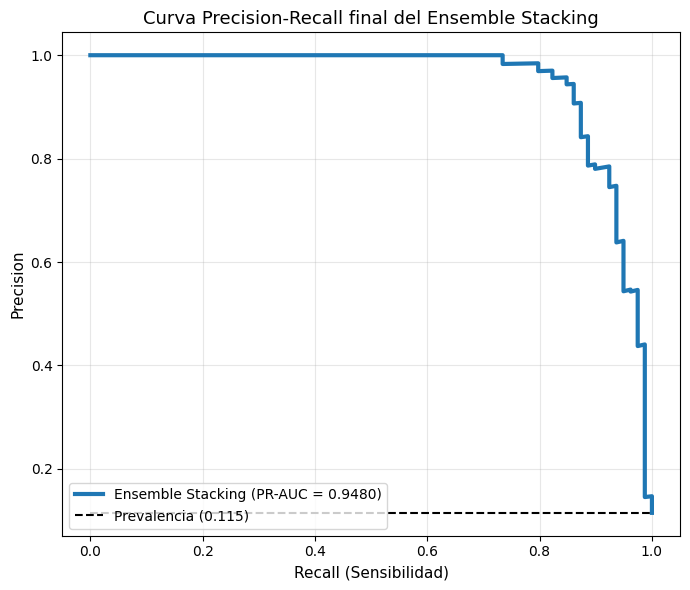

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    proba_test_stack
)

plt.figure(figsize=(7,6))

# Curva Precision-Recall
plt.plot(
    recall_curve,
    precision_curve,
    linewidth=3,
    label=f"Ensemble Stacking (PR-AUC = {pr_auc_stack_test:.4f})"
)

# Línea base (prevalencia)
plt.hlines(
    y=y_test.mean(),
    xmin=0,
    xmax=1,
    colors='black',
    linestyles='--',
    label=f'Prevalencia ({y_test.mean():.3f})'
)

plt.xlabel("Recall (Sensibilidad)", fontsize=11)
plt.ylabel("Precision", fontsize=11)

plt.title(
    "Curva Precision-Recall final del Ensemble Stacking",
    fontsize=13
)

plt.legend(loc="lower left")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Comparación Validation vs Test

In [ ]:
comparacion_val_test = pd.DataFrame([
    {
        "Conjunto": "Validation",
        "Accuracy": acc_val_stack,
        "Precision": precision_val_stack,
        "Recall": recall_val_stack,
        "F1-score": f1_val_stack,
        "ROC-AUC": roc_auc_val_stack,
        "PR-AUC": pr_auc_val_stack
    },

    {
        "Conjunto": "Test",
        "Accuracy": acc_stack,
        "Precision": precision_stack,
        "Recall": recall_stack,
        "F1-score": f1_stack,
        "ROC-AUC": roc_auc_stack_test,
        "PR-AUC": pr_auc_stack_test
    }
])

print("===== COMPARACIÓN VALIDATION VS TEST =====")

display(comparacion_val_test.round(4))

===== COMPARACIÓN VALIDATION VS TEST =====


,Conjunto,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Validation,0.9606,0.7708,0.9367,0.8457,0.9928,0.9604
1,Test,0.9520,0.7255,0.9367,0.8177,0.9823,0.9480


**Resumen de Desiciones**

- El modelo Ensemble **Stacking** fue evaluado sobre el conjunto **Test**, reservado exclusivamente para la validación final del sistema predictivo.
- En el conjunto Test, el modelo obtuvo un **Accuracy de 95.20 %, Recall de 93.67 %, ROC-AUC de 0.9822 y PR-AUC de 0.9480**, evidenciando una elevada capacidad discriminativa y un buen desempeño sobre la clase minoritaria.
- La matriz de confusión mostró que el sistema clasificó correctamente **74 gestantes con preeclampsia y 580 sin preeclampsia**, produciendo únicamente **5 falsos negativos**, aspecto prioritario en un contexto clínico por la necesidad de minimizar los casos no detectados.
- Las curvas ROC y Precision-Recall confirmaron la robustez del modelo, alcanzando valores elevados de ROC-AUC y PR-AUC en datos no observados durante el entrenamiento.
- La comparación entre los conjuntos Validation y Test evidenció un comportamiento consistente, manteniendo el mismo nivel de sensibilidad (Recall = 0.9367) y presentando únicamente ligeras disminuciones en Accuracy, ROC-AUC y PR-AUC, lo que sugiere una adecuada capacidad de generalización y ausencia de sobreajuste significativo.
- En consecuencia, el sistema predictivo basado en **Ensemble Stacking **fue validado satisfactoriamente y demostró ser una alternativa adecuada para la detección temprana del riesgo de preeclampsia en gestantes.

## **FASE 6: EXPLICABILIDAD Y VALIDACIÓN FINAL**

Interpretar las variables clínicas que más influyen en la detección temprana del riesgo de preeclampsia mediante técnicas de Inteligencia Artificial Explicable (XAI).

### 1. Preparación del modelo explicativo

In [ ]:
!pip install shap -q

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente.")

# Modelo seleccionado para explicabilidad
# Se usa RF por su alto rendimiento y compatibilidad con SHAP

rf_xai = best_estimators["RF"]

rf_xai.fit(X_train, y_train)

print("Modelo explicativo Random Forest entrenado correctamente.")

# Transformación de datos para SHAP

X_train_transformed = rf_xai.named_steps["preprocessor"].transform(X_train)
X_test_transformed = rf_xai.named_steps["preprocessor"].transform(X_test)

feature_names = numeric_features + binary_features

X_train_shap = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

print("Datos transformados para SHAP:")
print(X_train_shap.shape)
print(X_test_shap.shape)

Librerías cargadas correctamente.
Modelo explicativo Random Forest entrenado correctamente.
Datos transformados para SHAP:
(3201, 8)
(687, 8)


### 2.  Obtención de valores SHAP

In [ ]:
rf_model = rf_xai.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

shap_values_raw = explainer.shap_values(X_test_shap)

# Ajuste robusto del formato SHAP para clase positiva
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
elif len(shap_values_raw.shape) == 3:
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

print("Valores SHAP calculados correctamente.")
print("Shape SHAP:", shap_values.shape)

Valores SHAP calculados correctamente.
Shape SHAP: (687, 8)


### 3. Interpretación global del modelo

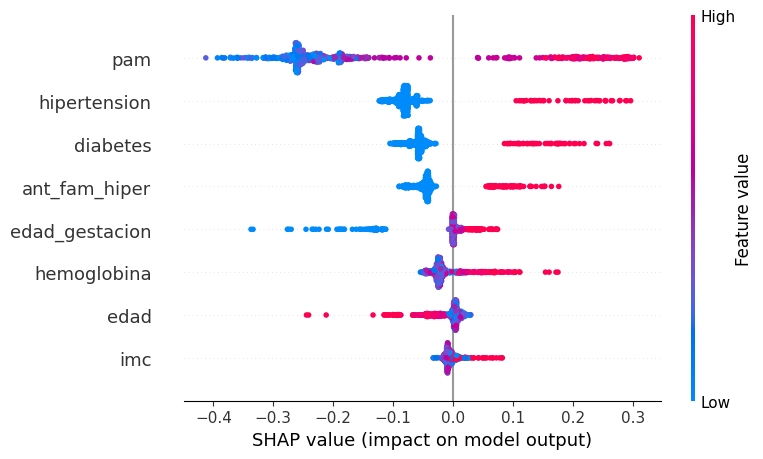

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Summary plot tipo beeswarm

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    show=True
)

In [ ]:
# Ranking global de importancia SHAP

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia_SHAP": mean_abs_shap
}).sort_values(
    by="Importancia_SHAP",
    ascending=False
)

display(shap_importance_df.round(4))

,Variable,Importancia_SHAP
3,pam,0.2331
5,hipertension,0.0888
6,diabetes,0.0678
7,ant_fam_hiper,0.0550
1,edad_gestacion,0.0288
4,hemoglobina,0.0285
0,edad,0.0172
2,imc,0.0095


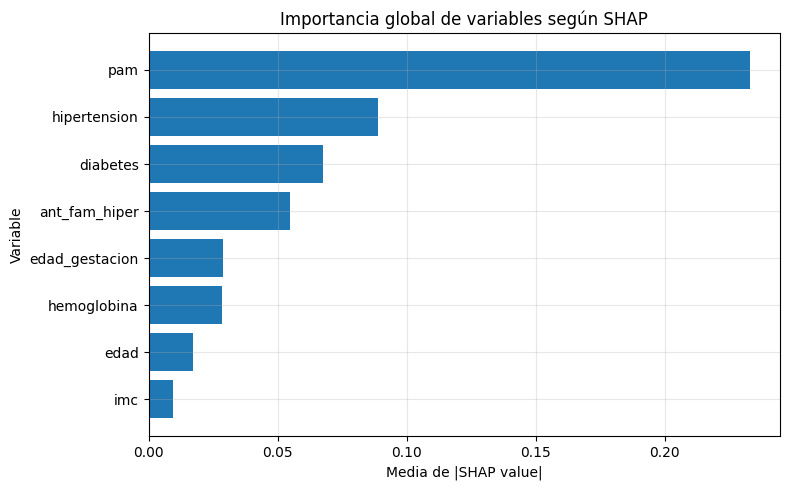

In [ ]:
# Gráfico de barras de importancia global

plt.figure(figsize=(8, 5))

plt.barh(
    shap_importance_df["Variable"],
    shap_importance_df["Importancia_SHAP"]
)

plt.gca().invert_yaxis()
plt.title("Importancia global de variables según SHAP")
plt.xlabel("Media de |SHAP value|")
plt.ylabel("Variable")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

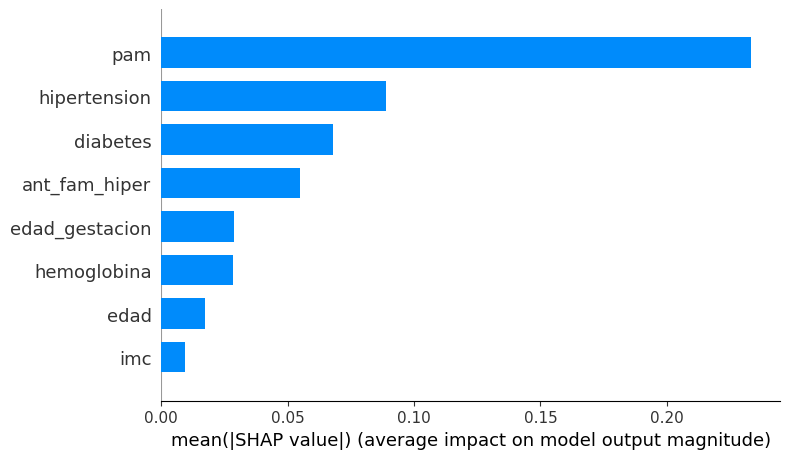

In [ ]:
# Bar plot nativo de SHAP

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

### 4. Interpretación local de predicciones

In [ ]:
# Selección de un caso positivo correctamente predicho

proba_test_rf = rf_xai.predict_proba(X_test)[:, 1]
pred_test_rf = (proba_test_rf >= 0.50).astype(int)

casos_positivos = np.where(
    (y_test.values == 1) & (pred_test_rf == 1)
)[0]

caso_idx = casos_positivos[0]

print("Caso seleccionado:", caso_idx)
print("Valor real:", y_test.values[caso_idx])
print("Probabilidad predicha:", round(proba_test_rf[caso_idx], 4))

Caso seleccionado: 2
Valor real: 1
Probabilidad predicha: 0.9653


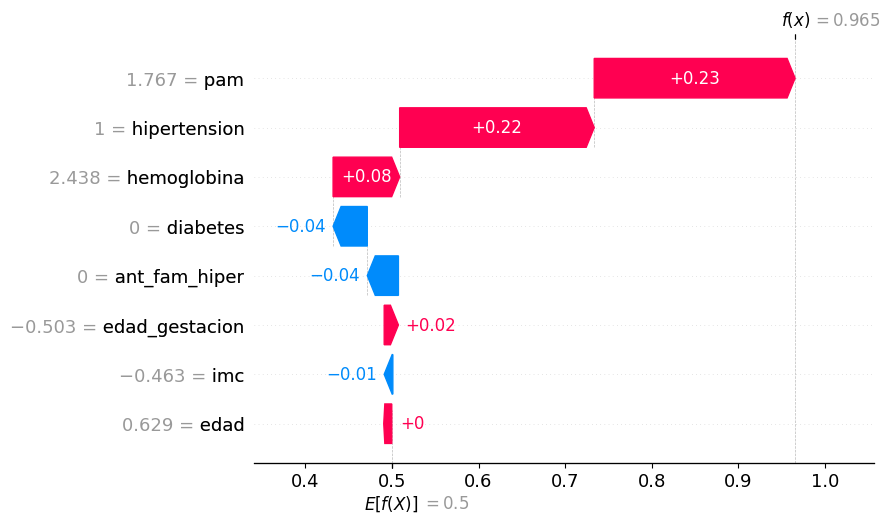

In [ ]:
import numpy as np
# Waterfall plot para explicación local

expected_value = explainer.expected_value

# Ensure expected_value_pos is a scalar for the positive class
if isinstance(expected_value, (list, np.ndarray)) and len(expected_value) > 1:
    expected_value_pos = expected_value[1] # Take the base value for the positive class
else:
    expected_value_pos = expected_value # Otherwise, use it as is (for single output models)

shap_exp = shap.Explanation(
    values=shap_values[caso_idx],
    base_values=expected_value_pos,
    data=X_test_shap.iloc[caso_idx],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp, max_display=10)

### 5. Interpretación clínica y validación final

In [ ]:
top_variables = shap_importance_df.head(5)["Variable"].tolist()

print("===== INTERPRETACIÓN FINAL XAI =====")

print("\nVariables clínicas más influyentes según SHAP:")
for var in top_variables:
    print("-", var)

print(
    "\nLos resultados SHAP permiten identificar las variables que más contribuyen "
    "a la predicción del riesgo de preeclampsia. Las variables con mayor importancia "
    "global representan los factores que más influyeron en las decisiones del modelo."
)

print(
    "\nLa explicación local mediante Waterfall Plot permite observar cómo cada variable "
    "incrementa o disminuye el riesgo estimado para una gestante específica."
)

print(
    "\nEn conjunto, la Fase 6 aporta interpretabilidad al sistema predictivo, "
    "fortaleciendo la transparencia del modelo y su posible utilidad como herramienta "
    "de apoyo a la detección temprana del riesgo de preeclampsia."
)

===== INTERPRETACIÓN FINAL XAI =====

Variables clínicas más influyentes según SHAP:
- pam
- hipertension
- diabetes
- ant_fam_hiper
- edad_gestacion

Los resultados SHAP permiten identificar las variables que más contribuyen a la predicción del riesgo de preeclampsia. Las variables con mayor importancia global representan los factores que más influyeron en las decisiones del modelo.

La explicación local mediante Waterfall Plot permite observar cómo cada variable incrementa o disminuye el riesgo estimado para una gestante específica.

En conjunto, la Fase 6 aporta interpretabilidad al sistema predictivo, fortaleciendo la transparencia del modelo y su posible utilidad como herramienta de apoyo a la detección temprana del riesgo de preeclampsia.


La Presión Arterial Media **PAM** fue identificada como el **factor de mayor contribución en la predicción del riesgo de preeclampsia**, confirmando su relevancia clínica como indicador temprano de alteraciones hemodinámicas durante la gestación.